# COS760 Group 45: Machine-Generated Text Detection

This notebook reproduces the main experimental pipeline for the project.  
The experiments are organised according to the three project phases:

- Phase 1: Dataset preparation and baseline classification
- Phase 2: Fine-tuned AfroXLMR inference
- Phase 3: SADiLaR feature augmentation and final evaluation

## Setup


In [67]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
import os

PROJECT_DIR = "/content/drive/MyDrive/COS760-Group-45-main"
CODE_DIR = os.path.join(PROJECT_DIR, "code")

os.chdir(CODE_DIR)
print(os.getcwd())

/content/drive/MyDrive/COS760-Group-45-main/code


In [69]:
BASE_PATH = PROJECT_DIR
RAW_PATH = os.path.join(BASE_PATH, "data", "raw")
PROCESSED_PATH = os.path.join(BASE_PATH, "data", "processed")
RESULTS_PATH = os.path.join(BASE_PATH, "results")

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(os.path.join(RESULTS_PATH, "metrics"), exist_ok=True)
os.makedirs(os.path.join(RESULTS_PATH, "plots"), exist_ok=True)

print("Raw data path:", RAW_PATH)
print("Processed data path:", PROCESSED_PATH)
print("Results path:", RESULTS_PATH)

Raw data path: /content/drive/MyDrive/COS760-Group-45-main/data/raw
Processed data path: /content/drive/MyDrive/COS760-Group-45-main/data/processed
Results path: /content/drive/MyDrive/COS760-Group-45-main/results


# Phase 1: Baseline Model (TF-IDF + Logistic Regression)


##Dataset Preparation

This section prepares the dataset used for the baseline and later phases.

The human-written texts are loaded from the Vukuzenzele monolingual dataset using Hugging Face.  
Machine-generated texts from Claude, ChatGPT and Gemini are loaded from local CSV files.  
The two sources are then merged into a single dataset with the following fields:

- `Text_Generated`: the text sample
- `Language_Code`: language identifier (`zu`, `xh`, `ss`)
- `Model_Identifier`: human, Claude, ChatGPT or Gemini
- `Label`: 0 for human-written and 1 for machine-generated

The script also removes artefacts that could make classification too easy, including numeric tracking artefacts and repeated formulaic opening phrases. Finally, all texts are truncated to approximately 800 characters at sentence boundaries.

In [82]:
#Phase 1 dataset preparation, loads human text from HuggingFace and MGT from all three LLMs, merges into merged_dataset.csv. Run before baseline.py.
import os
import re
import pandas as pd
from datasets import load_dataset

print("imports ok")

# Paths are already defined in the setup section.
# BASE_PATH = PROJECT_DIR
# RAW_PATH = data/raw
# PROCESSED_PATH = data/processed

os.makedirs(PROCESSED_PATH, exist_ok=True)

print(f"raw path: {RAW_PATH}")
print(f"processed path: {PROCESSED_PATH}")


def load_vukuzenzele(lang_code: str, hf_code: str) -> pd.DataFrame:
    ds= load_dataset("dsfsi/vukuzenzele-monolingual", hf_code)
    frames= [pd.DataFrame(ds[split]) for split in ds]
    combined= pd.concat(frames, ignore_index=True)

    if "text" in combined.columns:
        combined.rename(columns={"text": "Text_Generated"}, inplace=True)

    combined["Language_Code"]= lang_code
    combined["Model_Identifier"]= "human"
    combined["Label"]= 0

    return combined[["Text_Generated", "Language_Code", "Model_Identifier", "Label"]]


print("\nloading Vukuzenzele human text...")
zulu_human= load_vukuzenzele("zu", "zul");  print(f"  isiZulu  : {len(zulu_human)}")
xhosa_human= load_vukuzenzele("xh", "xho");  print(f"  isiXhosa : {len(xhosa_human)}")
siswati_human= load_vukuzenzele("ss", "ssw");  print(f"  Siswati  : {len(siswati_human)}")

human_df= pd.concat([zulu_human, xhosa_human, siswati_human], ignore_index=True)
print(f"\ntotal human: {len(human_df)}")

MGT_FILES = {
    "Claude": os.path.join(RAW_PATH, "machine_generated_claude.csv"),
    "ChatGPT": os.path.join(RAW_PATH, "machine_generated_chatgpt-4o.csv"),
    "Gemini": os.path.join(RAW_PATH, "machine_generated_gemini-2.5-pro.csv"),
}

mgt_frames = []
for model_name, filepath in MGT_FILES.items():
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"MGT file for {model_name} not found: {filepath}")
    df_tmp = pd.read_csv(filepath)
    print(f"\n{model_name}: {len(df_tmp)} records | {df_tmp['Language_Code'].value_counts().to_dict()}")
    mgt_frames.append(df_tmp)

machine_df = pd.concat(mgt_frames, ignore_index=True)
machine_df["Label"] = 1
machine_df = machine_df[["Text_Generated", "Language_Code", "Model_Identifier", "Label"]]

#remove the ChatGPT numeric tracking artefact that appears in every ChatGPT row and zero human rows.
def clean_text(text: str) -> str:
    text= re.sub(r'ngenombolo\s+\d+-\d+-\d+', '', text)
    text= re.sub(r'\b\d+-\d+-\d+\b', '', text)
    text= re.sub(r' {2,}', ' ', text)
    return text.strip()

before= machine_df["Text_Generated"].str.contains(r'\d+-\d+-\d+', regex=True).sum()
machine_df["Text_Generated"] = machine_df["Text_Generated"].apply(clean_text)
after = machine_df["Text_Generated"].str.contains(r'\d+-\d+-\d+', regex=True).sum()
print(f"\nArtefact rows cleaned: {before} -> {after}")

#Remove first sentence from MGT texts that start with formulaic patterns as they appear in 25-34% of MGT texts but <1% of human texts, creating easy detection
FORMULAIC_STARTS = ["Ngaphezulu","Abahlali","Emaphandleni","Umasipala","Ekhuluma","Ngemuva"]

def remove_formulaic_first_sentence(text: str, is_mgt: bool) -> str:
    if not is_mgt:
        return text

    #Check if text starts with any formulaic pattern
    starts_with_formula = any(text.startswith(pattern) for pattern in FORMULAIC_STARTS)

    if not starts_with_formula:
        return text

    #Find the first sentence boundary (. ! ?)
    match = re.search(r'[.!?](?=\s|$)', text)

    if match:
        #Remove everything up to and including the first sentence boundary
        remaining = text[match.end():].strip()
        if len(remaining) > 100:  # Only remove if there's substantial text remaining
            return remaining

    #If no sentence boundary found or remaining text too short, return original
    return text

before_removal = machine_df["Text_Generated"].apply(
    lambda t: any(t.startswith(p) for p in FORMULAIC_STARTS)
).sum()

machine_df["Text_Generated"] = machine_df.apply(
    lambda row: remove_formulaic_first_sentence(row["Text_Generated"], is_mgt=True),
    axis=1
)

after_removal = machine_df["Text_Generated"].apply(
    lambda t: any(t.startswith(p) for p in FORMULAIC_STARTS)
).sum()

print(f"\nformulaic first sentences removed: {before_removal} -> {after_removal}")

print(f"\ntotal MGT: {len(machine_df)}")
print(machine_df["Language_Code"].value_counts())
print(machine_df["Model_Identifier"].value_counts())

machine_df.to_csv(os.path.join(PROCESSED_PATH, "mgt_text.csv"), index=False)

combined_df = pd.concat([human_df, machine_df], ignore_index=True)
combined_df.dropna(subset=["Text_Generated"], inplace=True)
combined_df["Text_Generated"] = combined_df["Text_Generated"].astype(str).str.strip()
combined_df = combined_df[combined_df["Text_Generated"] != ""]

#truncate all texts to a target character length, cutting at the nearest sentence boundary
def truncate_to_sentence(text: str, max_chars: int = 800) -> str:
    if len(text) <= max_chars:
        return text

    truncated = text[:max_chars]

    #Find the last sentence boundary in the truncated portion
    import re
    boundaries = list(re.finditer(r'[.!?](?=\s|$)', truncated))

    if boundaries:
        #Cut at the last sentence boundary found
        last_boundary = boundaries[-1].end()
        return text[:last_boundary].strip()
    else:
        #No sentence boundary found,fall back to character truncation
        return truncated.strip()

TARGET_LENGTH = 800
print(f"\ntruncating texts to ~{TARGET_LENGTH} chars at sentence boundaries...")
before_human = combined_df.loc[combined_df["Label"]==0, "Text_Generated"].str.len().mean()
before_mgt   = combined_df.loc[combined_df["Label"]==1, "Text_Generated"].str.len().mean()

combined_df["Text_Generated"] = combined_df["Text_Generated"].apply(
    lambda t: truncate_to_sentence(t, TARGET_LENGTH)
)

after_human= combined_df.loc[combined_df["Label"]==0, "Text_Generated"].str.len().mean()
after_mgt= combined_df.loc[combined_df["Label"]==1, "Text_Generated"].str.len().mean()

print(f"human avg: {before_human:.0f} -> {after_human:.0f} chars")
print(f"MGT avg  : {before_mgt:.0f} -> {after_mgt:.0f} chars")

print(f"\ntotal after cleaning: {len(combined_df)}")
print(combined_df["Language_Code"].value_counts())
print(combined_df["Label"].value_counts())

output_path = os.path.join(PROCESSED_PATH, "merged_dataset.csv")
combined_df.to_csv(output_path, index=False)
print(f"\nsaved: {output_path}  shape: {combined_df.shape}")

imports ok
raw path: /content/drive/MyDrive/COS760-Group-45-main/data/raw
processed path: /content/drive/MyDrive/COS760-Group-45-main/data/processed

loading Vukuzenzele human text...
  isiZulu  : 185
  isiXhosa : 186
  Siswati  : 187

total human: 558

Claude: 150 records | {'zu': 50, 'xh': 50, 'ss': 50}

ChatGPT: 118 records | {'xh': 60, 'zu': 40, 'ss': 18}

Gemini: 141 records | {'xh': 50, 'zu': 49, 'ss': 42}

Artefact rows cleaned: 0 -> 0

formulaic first sentences removed: 303 -> 9

total MGT: 409
Language_Code
xh    160
zu    139
ss    110
Name: count, dtype: int64
Model_Identifier
claude-sonnet-4-6    150
gemini-2.5-pro       141
chatgpt-4o           118
Name: count, dtype: int64

truncating texts to ~800 chars at sentence boundaries...
human avg: 4010 -> 673 chars
MGT avg  : 988 -> 667 chars

total after cleaning: 953
Language_Code
xh    341
zu    319
ss    293
Name: count, dtype: int64
Label
0    544
1    409
Name: count, dtype: int64

saved: /content/drive/MyDrive/COS760-Grou

##Baseline Model

This phase develops a baseline machine-generated text detector using TF-IDF and Logistic Regression. The model is trained on isiZulu and isiXhosa texts and evaluated on both seen-language data and an unseen Siswati test set to assess cross-lingual generalisation. The results obtained in this phase provide a benchmark for comparison with the transfer learning and SADiLaR-augmented models developed in later phases.

all imports successful
loading dataset from: /content/drive/MyDrive/COS760-Group-45-main/data/processed/merged_dataset.csv

total records: 953
Language_Code
xh    341
zu    319
ss    293
Name: count, dtype: int64
Label
0    544
1    409
Name: count, dtype: int64

total records: 953
by language: {'xh': 341, 'zu': 319, 'ss': 293}
by label: {0: 544, 1: 409}

training pool (isiZulu + isiXhosa): 660
siswati held-out (zero-shot): 293

train: 528  test: 132

preprocessing: lowercasing and removing punctuation...

TF-IDF vocab size: 10000
train matrix: (528, 10000)
test matrix: (132, 10000)
siswati matrix: (293, 10000)

model trained

in-language test (isiZulu + isiXhosa)
  precision   : 0.9839
  recall      : 0.9861
  macro_f1    : 0.9848
  mcc         : 0.97
  auc_roc     : 1.0
  auc_pr      : 1.0
              precision    recall  f1-score   support

       Human       1.00      0.97      0.99        72
     Machine       0.97      1.00      0.98        60

    accuracy                     

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(



cross-LLM Siswati zero-shot (claude-sonnet-4-6)
  precision   : 0.5
  recall      : 0.1
  macro_f1    : 0.1667
  mcc         : 0.0
  auc_roc     : nan
  auc_pr      : nan
              precision    recall  f1-score   support

     Machine       1.00      0.20      0.33        50

   micro avg       1.00      0.20      0.33        50
   macro avg       1.00      0.20      0.33        50
weighted avg       1.00      0.20      0.33        50


cross-LLM Siswati zero-shot (gemini-2.5-pro)
  precision   : 0.5
  recall      : 0.2024
  macro_f1    : 0.2881
  mcc         : 0.0
  auc_roc     : nan
  auc_pr      : nan
              precision    recall  f1-score   support

     Machine       1.00      0.40      0.58        42

   micro avg       1.00      0.40      0.58        42
   macro avg       1.00      0.40      0.58        42
weighted avg       1.00      0.40      0.58        42



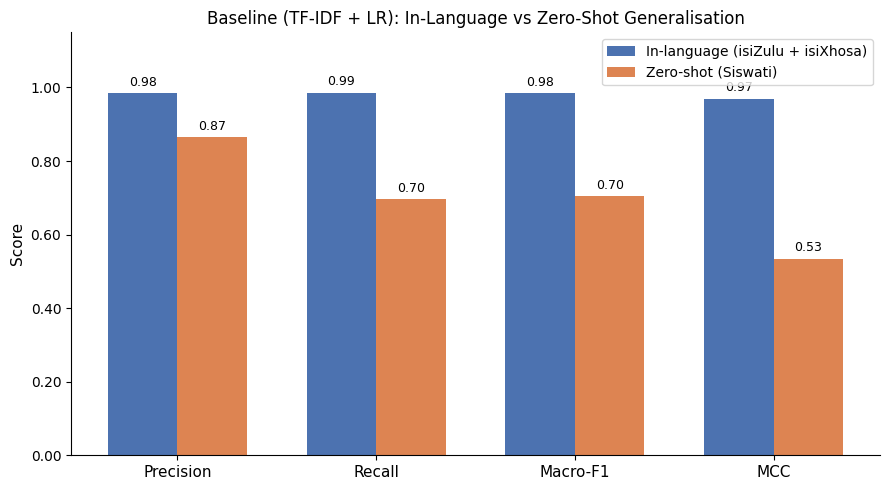

saved: /content/drive/MyDrive/COS760-Group-45-main/results/plots/baseline_generalisation_gap.png


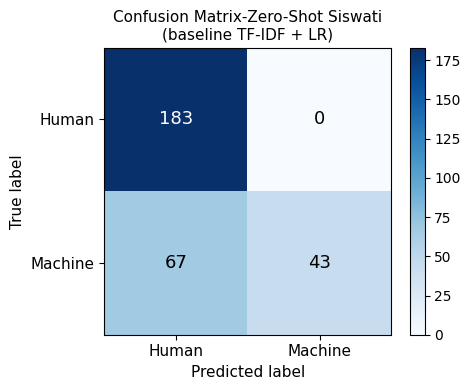

saved: /content/drive/MyDrive/COS760-Group-45-main/results/plots/baseline_siswati_confusion.png

metrics saved: /content/drive/MyDrive/COS760-Group-45-main/results/metrics/baseline_metrics.json

baseline summary
in-language macro-F1: 0.9848
in-language MCC: 0.97
siswati macro-F1: 0.7037  (zero-shot)
siswati MCC: 0.5349  (zero-shot)
CV macro-F1 (5-fold): 0.9863
Phase 2 AfroXLMR must beat these numbers


In [83]:
#Phase 1 baseline: TF-IDF + Logistic Regression (SGD) for MGT detection, trains on isiZulu and isiXhosa, tests zero-shot on Siswati
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_score, recall_score, f1_score,matthews_corrcoef, roc_auc_score,average_precision_score, confusion_matrix,classification_report)

print("all imports successful")

DATA_PATH = os.path.join(PROJECT_DIR, "data", "processed")
RESULTS_PATH = os.path.join(PROJECT_DIR, "results")

os.makedirs(os.path.join(RESULTS_PATH, "metrics"), exist_ok=True)
os.makedirs(os.path.join(RESULTS_PATH, "plots"),   exist_ok=True)

DATASET_FILE = os.path.join(DATA_PATH, "merged_dataset.csv")

if not os.path.exists(DATASET_FILE):
    raise FileNotFoundError(f"processed dataset not found at:\n  {DATASET_FILE}, please run code/dataset_prep.py first")

print(f"loading dataset from: {DATASET_FILE}")
df = pd.read_csv(DATASET_FILE)

print(f"\ntotal records: {len(df)}")
print(df["Language_Code"].value_counts())
print(df["Label"].value_counts())

print(f"\ntotal records: {len(df)}")
print(f"by language: {df['Language_Code'].value_counts().to_dict()}")
print(f"by label: {df['Label'].value_counts().to_dict()}")

#Texts are already truncated to ~800 chars at sentence boundaries in dataset_prep.py
train_df= df[df["Language_Code"].isin(["zu", "xh"])].copy()
siswati_df= df[df["Language_Code"] == "ss"].copy()

print(f"\ntraining pool (isiZulu + isiXhosa): {len(train_df)}")
print(f"siswati held-out (zero-shot): {len(siswati_df)}")

X = train_df["Text_Generated"]
y = train_df["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\ntrain: {len(X_train)}  test: {len(X_test)}")

#Preprocessing: lowercase and remove punctuation to eliminate capitalization
#and punctuation leakage. This forces the model to focus on morphological and
#lexical patterns rather than superficial formatting differences.
#Human texts have ~18 capitals vs MGT ~6 capitals (major leakage)
#Human texts have ~4 commas vs MGT ~2 commas (structural leakage)
import string

def clean_for_tfidf(text):
    """Remove punctuation and lowercase to eliminate formatting leakage."""
    text= text.lower()
    text= text.translate(str.maketrans('', '', string.punctuation))
    text= ' '.join(text.split())  # Normalize whitespace
    return text

print("\npreprocessing: lowercasing and removing punctuation...")
X_train_clean= X_train.apply(clean_for_tfidf)
X_test_clean= X_test.apply(clean_for_tfidf)
X_siswati_clean= siswati_df["Text_Generated"].apply(clean_for_tfidf)

tfidf= TfidfVectorizer(
    max_features=10000,
    ngram_range=(3, 6),
    sublinear_tf=True,
    strip_accents=None,
    analyzer="char_wb",
    min_df=5
)

X_train_tfidf= tfidf.fit_transform(X_train_clean)
X_test_tfidf= tfidf.transform(X_test_clean)
X_siswati_tfidf= tfidf.transform(X_siswati_clean)
y_siswati= siswati_df["Label"]

print(f"\nTF-IDF vocab size: {len(tfidf.vocabulary_)}")
print(f"train matrix: {X_train_tfidf.shape}")
print(f"test matrix: {X_test_tfidf.shape}")
print(f"siswati matrix: {X_siswati_tfidf.shape}")


clf = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000, solver="lbfgs")
clf.fit(X_train_tfidf, y_train)
print("\nmodel trained")


def evaluate_model(clf, X_vec, y_true, label="evaluation"):
    y_pred= clf.predict(X_vec)
    y_proba= clf.predict_proba(X_vec)[:, 1]

    unique_classes = np.unique(y_true)
    if len(unique_classes) < 2:
        auc_roc= float("nan")
        auc_pr = float("nan")
    else:
        auc_roc= round(roc_auc_score(y_true, y_proba), 4)
        auc_pr = round(average_precision_score(y_true, y_proba), 4)

    metrics = {
        "label": label,
        "precision": round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "recall": round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "macro_f1": round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "mcc": round(matthews_corrcoef(y_true, y_pred), 4),
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
    }

    print(f"\n{label}")
    for k, v in metrics.items():
        if k != "label":
            print(f"  {k:<12}: {v}")

    present_labels = sorted(unique_classes)
    target_names   = [["Human", "Machine"][i] for i in present_labels]
    print(classification_report(y_true, y_pred, labels=present_labels, target_names=target_names))

    return metrics, y_pred, y_proba


metrics_inlang, y_pred_inlang, _ = evaluate_model(
    clf, X_test_tfidf, y_test,
    label="in-language test (isiZulu + isiXhosa)"
)

metrics_siswati, y_pred_siswati, _ = evaluate_model(
    clf, X_siswati_tfidf, y_siswati,
    label="zero-shot cross-lingual test (Siswati)"
)

#5-fold stratified cross-validation on the full training pool, apply same preprocessing (lowercase + remove punctuation)
X_all_clean= train_df["Text_Generated"].apply(clean_for_tfidf)
y_all= train_df["Label"]

pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10000,
        ngram_range=(3, 6),
        sublinear_tf=True,
        strip_accents=None,
        analyzer="char_wb",
        min_df=5
    )),
    ("clf", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000,
        tol=1e-3
    ))
])

skf= StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_preds= cross_val_predict(pipeline, X_all_clean, y_all, cv=skf)
cv_probas= cross_val_predict(pipeline, X_all_clean, y_all, cv=skf, method="predict_proba")[:, 1]

cv_metrics = {
    "label": "5-fold cross validation",
    "macro_f1": round(f1_score(y_all, cv_preds, average="macro"), 4),
    "mcc": round(matthews_corrcoef(y_all, cv_preds), 4),
    "auc_roc": round(roc_auc_score(y_all, cv_probas), 4),
}

print("\n5-fold cross-validation")
for k, v in cv_metrics.items():
    if k != "label":
        print(f"  {k:<12}: {v}")

#cross-LLM generalisation
print("\ncross-LLM generalisation (in-language test set)")

llm_metrics = {}
for llm in sorted(train_df["Model_Identifier"].unique()):
    if llm == "human":
        continue
    mask= train_df.loc[X_test.index, "Model_Identifier"] == llm
    X_test_llm= X_test[mask]
    y_test_llm= y_test[mask]
    if len(X_test_llm) == 0:
        continue
    #apply same preprocessing
    X_test_llm_clean = X_test_llm.apply(clean_for_tfidf)
    m, _, _ = evaluate_model(
        clf, tfidf.transform(X_test_llm_clean), y_test_llm,
        label=f"cross-LLM in-language ({llm})"
    )
    llm_metrics[llm] = m
print("\ncross-LLM generalisation (Siswati zero-shot)")

llm_siswati_metrics = {}
for llm in sorted(siswati_df["Model_Identifier"].unique()):
    if llm == "human":
        continue
    mask= siswati_df["Model_Identifier"] == llm
    X_ss_llm = siswati_df.loc[mask, "Text_Generated"]
    y_ss_llm = siswati_df.loc[mask, "Label"]
    if len(X_ss_llm) == 0:
        continue
    # Apply same preprocessing
    X_ss_llm_clean = X_ss_llm.apply(clean_for_tfidf)
    m, _, _ = evaluate_model(
        clf, tfidf.transform(X_ss_llm_clean), y_ss_llm,
        label=f"cross-LLM Siswati zero-shot ({llm})"
    )
    llm_siswati_metrics[llm] = m

#shows the generalisation gap across Precision, Recall, Macro-F1 and MCC, include the four metrics the proposal uses to evaluate the baseline.
metric_keys= ["precision", "recall", "macro_f1", "mcc"]
metric_labels= ["Precision", "Recall", "Macro-F1", "MCC"]
inlang_vals= [metrics_inlang[k]  for k in metric_keys]
siswati_vals = [metrics_siswati[k] for k in metric_keys]

x= np.arange(len(metric_keys))
width = 0.35

fig, ax= plt.subplots(figsize=(9, 5))
bars1= ax.bar(x - width / 2, inlang_vals,  width, color="#4C72B0", label="In-language (isiZulu + isiXhosa)")
bars2= ax.bar(x + width / 2, siswati_vals, width, color="#DD8452", label="Zero-shot (Siswati)")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Baseline (TF-IDF + LR): In-Language vs Zero-Shot Generalisation", fontsize=12)
ax.legend(fontsize=10)
ax.bar_label(bars1, fmt="%.2f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.2f", padding=3, fontsize=9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plot1_path = os.path.join(RESULTS_PATH, "plots", "baseline_generalisation_gap.png")
plt.savefig(plot1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved: {plot1_path}")

#confusion matrix for Siswati zero-shot only, shows the actual error pattern: the model is biased toward predicting Machine, causing it to miss most Human texts.
cm = confusion_matrix(y_siswati, y_pred_siswati)
labels = ["Human", "Machine"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel("Predicted label", fontsize=11)
ax.set_ylabel("True label", fontsize=11)
ax.set_title("Confusion Matrix-Zero-Shot Siswati\n(baseline TF-IDF + LR)", fontsize=11)

thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=13)

plt.tight_layout()
plot2_path = os.path.join(RESULTS_PATH, "plots", "baseline_siswati_confusion.png")
plt.savefig(plot2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved: {plot2_path}")

all_metrics = {
    "in_language": metrics_inlang,
    "siswati_zeroshot": metrics_siswati,
    "cross_validation": cv_metrics,
}
for llm, m in llm_metrics.items():
    all_metrics[f"cross_llm_{llm}"] = m
for llm, m in llm_siswati_metrics.items():
    all_metrics[f"cross_llm_siswati_{llm}"] = m

metrics_path = os.path.join(RESULTS_PATH, "metrics", "baseline_metrics.json")
with open(metrics_path, "w") as f:
    json.dump(all_metrics, f, indent=2)
print(f"\nmetrics saved: {metrics_path}")

print("\nbaseline summary")
print(f"in-language macro-F1: {metrics_inlang['macro_f1']}")
print(f"in-language MCC: {metrics_inlang['mcc']}")
print(f"siswati macro-F1: {metrics_siswati['macro_f1']}  (zero-shot)")
print(f"siswati MCC: {metrics_siswati['mcc']}  (zero-shot)")
print(f"CV macro-F1 (5-fold): {cv_metrics['macro_f1']}")
print("Phase 2 AfroXLMR must beat these numbers")

The TF-IDF and Logistic Regression baseline achieved strong in-language performance on isiZulu and isiXhosa, but its performance dropped in the zero-shot Siswati setting. This shows that the traditional baseline has weaker cross-lingual generalisation, motivating the use of AfroXLMR transfer learning in Phase 2.

# Phase 2: AfroXLMR Inference

This phase evaluates the fine-tuned AfroXLMR model developed in Phase 2. To ensure reproducibility and reduce computational requirements, the model is not retrained in this notebook. Instead, the best-performing saved model is loaded and used to generate predictions and evaluation metrics on the test datasets.

The complete model training and fine-tuning procedure is provided separately in `finetuning_afrolxm.ipynb`.

## Load Fine-Tuned Model

The best-performing AfroXLMR model obtained during Phase 2 fine-tuning is loaded from the `best from phase 2` directory. This model is then used to generate predictions for in-language and zero-shot evaluation.

In [72]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "/content/drive/MyDrive/COS760-Group-45-main/code/best from phase 2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

print("Model loaded successfully")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully


## Evaluation
This section evaluates the fine-tuned AfroXLMR model on the unseen Siswati test set. The objective is to assess the model's ability to transfer knowledge learned from isiZulu and isiXhosa to a related low-resource language that was not observed during training. Performance is measured using precision, recall, macro F1-score, Matthews Correlation Coefficient (MCC), confusion matrices, and additional evaluation metrics. The results provide insight into the effectiveness of cross-lingual transfer learning for machine-generated text detection in low-resource African languages.

In [93]:
# Generate predictions for all Siswati test samples using the fine-tuned AfroXLMR model.
# Each text is tokenised and passed through the model to obtain the predicted class
# (Human or Machine). The predictions are then compared with the true labels to
# produce a classification report and confusion matrix, allowing the model's
# cross-lingual performance on the unseen Siswati test set to be evaluated.
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

texts = siswati_df["Text_Generated"].astype(str).tolist()
true_labels = siswati_df["Label"].astype(int).values

all_preds = []

for text in texts:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        logits = afroxlmr(**inputs).logits

    pred = torch.argmax(logits, dim=1).item()
    all_preds.append(pred)

ft_preds = np.array(all_preds)

print("Fine-tuned AfroXLMR on Siswati Report")
print("-" * 55)

print("\nClassification Report:")
print(classification_report(
    true_labels,
    ft_preds,
    target_names=["Human", "Machine"],
    digits=4
))

cm = confusion_matrix(true_labels, ft_preds)

print("Confusion Matrix (rows=true, cols=predicted):")
print(f"                Pred:Human  Pred:Machine")
print(f"  True:Human       {cm[0,0]:>6}        {cm[0,1]:>6}")
print(f"  True:Machine     {cm[1,0]:>6}        {cm[1,1]:>6}")

Fine-tuned AfroXLMR on Siswati Report
-------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

       Human     0.9015    1.0000    0.9482       183
     Machine     1.0000    0.8182    0.9000       110

    accuracy                         0.9317       293
   macro avg     0.9507    0.9091    0.9241       293
weighted avg     0.9385    0.9317    0.9301       293

Confusion Matrix (rows=true, cols=predicted):
                Pred:Human  Pred:Machine
  True:Human          183             0
  True:Machine         20            90


In [94]:
# Compare Phase 1 baseline performance with the Phase 2 AfroXLMR model on the
# Siswati zero-shot test set.
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef
)

print("Comparing TF-IDF Baseline (Phase 1) vs AfroXLMR (Phase 2)")
print("On Siswati zero-shot / cross-lingual test set")
print("-" * 55)

PHASE1_METRICS_JSON = "/content/drive/MyDrive/COS760-Group-45-main/results/metrics/baseline_metrics.json"

if os.path.exists(PHASE1_METRICS_JSON):
    with open(PHASE1_METRICS_JSON) as f:
        phase1_all = json.load(f)
    phase1 = phase1_all.get("siswati_zeroshot", {})
    print(f"Loaded Phase 1 metrics from {PHASE1_METRICS_JSON}\n")
else:
    print(f"Phase 1 metrics not found at {PHASE1_METRICS_JSON}")
    phase1 = {}

phase2 = {
    "precision": round(precision_score(true_labels, ft_preds, average="macro", zero_division=0), 4),
    "recall": round(recall_score(true_labels, ft_preds, average="macro", zero_division=0), 4),
    "macro_f1": round(f1_score(true_labels, ft_preds, average="macro", zero_division=0), 4),
    "mcc": round(matthews_corrcoef(true_labels, ft_preds), 4),
}

metrics_to_compare = ["precision", "recall", "macro_f1", "mcc"]

header = f"  {'Metric':<14} {'TF-IDF + LR':>14} {'AfroXLMR FT':>14} {'Δ Change':>12}"
print(header)
print("  " + "-" * (len(header) - 2))

for m in metrics_to_compare:
    p1_val = phase1.get(m, float("nan"))
    p2_val = phase2.get(m, float("nan"))

    delta = p2_val - p1_val if not (np.isnan(p1_val) or np.isnan(p2_val)) else float("nan")
    delta_str = f"{delta:+.4f}" if not np.isnan(delta) else "N/A"

    print(f"  {m:<14} {p1_val:>14.4f} {p2_val:>14.4f} {delta_str:>12}")

f1_delta = phase2["macro_f1"] - phase1.get("macro_f1", float("nan"))

if not np.isnan(f1_delta):
    improved = f1_delta > 0
    print(
        f"\n{'Good' if improved else 'Bad'}: AfroXLMR "
        f"{'outperforms' if improved else 'underperforms'} "
        f"the TF-IDF baseline on Siswati by {f1_delta:+.4f} Macro-F1."
    )

Comparing TF-IDF Baseline (Phase 1) vs AfroXLMR (Phase 2)
On Siswati zero-shot / cross-lingual test set
-------------------------------------------------------
Loaded Phase 1 metrics from /content/drive/MyDrive/COS760-Group-45-main/results/metrics/baseline_metrics.json

  Metric            TF-IDF + LR    AfroXLMR FT     Δ Change
  ---------------------------------------------------------
  precision              0.8660         0.9507      +0.0847
  recall                 0.6955         0.9091      +0.2136
  macro_f1               0.7037         0.9241      +0.2204
  mcc                    0.5349         0.8588      +0.3239

Good: AfroXLMR outperforms the TF-IDF baseline on Siswati by +0.2204 Macro-F1.


In [104]:
# Save the Phase 2 AfroXLMR evaluation metrics in the format expected by Phase 3.
# Prediction probabilities are also used to calculate AUC-ROC and AUC-PR for the
# machine-generated class, allowing Phase 3 to load and compare these results.
import json
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score
)

# Get probability for Machine class
all_probs = []

for text in siswati_df["Text_Generated"].astype(str).tolist():
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        logits = afroxlmr(**inputs).logits

    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    all_probs.append(probs)

all_probs = np.array(all_probs)
machine_probs = all_probs[:, 1]

phase2_metrics = {
    "model": "AfroXLMR",
    "train_languages": ["zu", "xh"],
    "test_language": "ss",
    "siswati_crosslingual": {
        "precision": round(precision_score(true_labels, ft_preds, average="macro"), 4),
        "recall": round(recall_score(true_labels, ft_preds, average="macro"), 4),
        "macro_f1": round(f1_score(true_labels, ft_preds, average="macro"), 4),
        "mcc": round(matthews_corrcoef(true_labels, ft_preds), 4),
        "auc_roc": round(roc_auc_score(true_labels, machine_probs), 4),
        "auc_pr": round(average_precision_score(true_labels, machine_probs), 4),
    }
}

out_path = "/content/drive/MyDrive/COS760-Group-45-main/results/metrics/phase2_afroxlmr_metrics.json"

with open(out_path, "w") as f:
    json.dump(phase2_metrics, f, indent=2)

print(f"Phase 2 metrics saved to:\n{out_path}")
print(json.dumps(phase2_metrics, indent=2))

Phase 2 metrics saved to:
/content/drive/MyDrive/COS760-Group-45-main/results/metrics/phase2_afroxlmr_metrics.json
{
  "model": "AfroXLMR",
  "train_languages": [
    "zu",
    "xh"
  ],
  "test_language": "ss",
  "siswati_crosslingual": {
    "precision": 0.9507,
    "recall": 0.9091,
    "macro_f1": 0.9241,
    "mcc": 0.8588,
    "auc_roc": 0.9988,
    "auc_pr": 0.998
  }
}


In [96]:
# Generate sample predictions using the fine-tuned AfroXLMR model to illustrate
# how individual Siswati texts are classified. For each document, the predicted
# label is compared with the true label and the model's confidence scores can be
# inspected to better understand its decision-making behaviour.
def predict(text: str, verbose=True):
    afroxlmr.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(device)

    with torch.no_grad():
        logits = afroxlmr(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze()
    pred_id = probs.argmax().item()

    if verbose:
        print(f"Text       : {text[:80]}{'...' if len(text) > 80 else ''}")
        print(f"Prediction : {ID2LABEL[pred_id].upper()}")
        print(f"Confidence : Human={probs[0]:.3f}  Machine={probs[1]:.3f}\n")

    return ID2LABEL[pred_id], probs.tolist()


print("\n" + "=" * 55)
print("Sample Siswati Prediction")
print("=" * 55 + "\n")

for row in siswati_df.head(8).itertuples():
    pred, _ = predict(row.Text_Generated, verbose=False)
    match = LABEL2ID[pred] == row.Label

    print(
        f"{'Good' if match else 'Bad'} "
        f"True: {ID2LABEL[row.Label]:<8} | "
        f"Predicted: {pred:<8} | "
        f"{row.Text_Generated[:60]}"
    )


Sample Siswati Prediction

Good True: human    | Predicted: human    | Kube ngumsebenti loma tima kakhulu kuvumbulula lokuchumana l
Good True: human    | Predicted: human    | “Siyakuvisisa lokubaluleka kwesikhatsi nekugcina sikhatsi le
Good True: human    | Predicted: human    | Lesikhungo sivulelwe ku sita bantfu labatisulu teku hlukunye
Good True: human    | Predicted: human    | Labalimi laba-30 batfole ematayitela alomhlaba ku Mengameli 
Good True: human    | Predicted: human    | “Kusebentisa imali ngalo kwendlulele kufana nesi kweleti les
Good True: human    | Predicted: human    | Akhuluma nesive muva nje ngalokwentekako mayelana nendlelali
Good True: human    | Predicted: human    | I-COVID-19 ligciwane lelihlasela titfo temtimba tekuphefumul
Good True: human    | Predicted: human    | Noma ‘iriphabhlikhi’ icha zwa njengelive lapho khona emandla


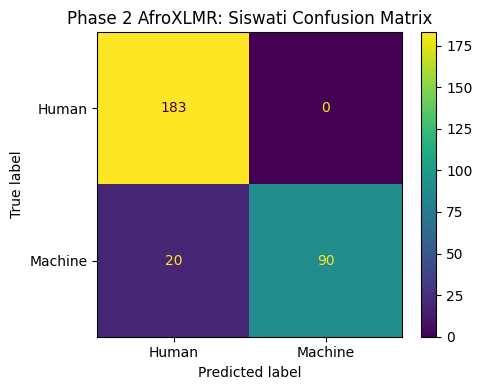

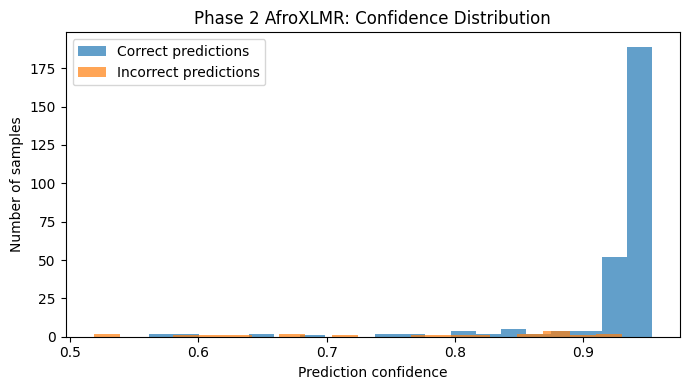

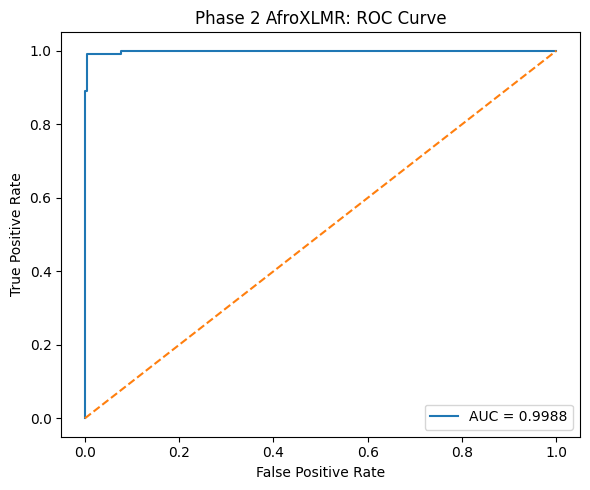

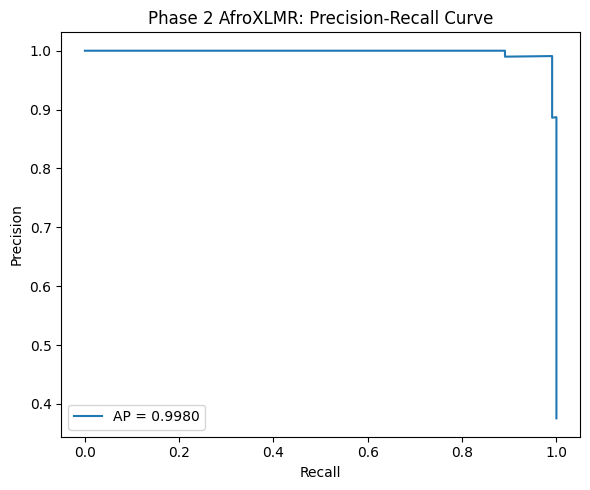

Phase 2 plots saved to: /content/drive/MyDrive/COS760-Group-45-main/results/plots/phase2


In [108]:
# Phase 2 visualisations: confidence distribution, ROC curve, PR curve, and confusion matrix

import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

PHASE2_PLOTS_DIR = "/content/drive/MyDrive/COS760-Group-45-main/results/plots/phase2"
os.makedirs(PHASE2_PLOTS_DIR, exist_ok=True)

# Get probability scores for the Machine class
texts = siswati_df["Text_Generated"].astype(str).tolist()
all_probs = []

afroxlmr.eval()

for text in texts:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256
    ).to(device)

    with torch.no_grad():
        logits = afroxlmr(**inputs).logits

    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    all_probs.append(probs)

all_probs = np.array(all_probs)
machine_probs = all_probs[:, 1]

# 1. Confusion Matrix
cm = confusion_matrix(true_labels, ft_preds)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Human", "Machine"]
).plot(ax=ax)

plt.title("Phase 2 AfroXLMR: Siswati Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(PHASE2_PLOTS_DIR, "phase2_confusion_matrix.png"), dpi=300)
plt.show()

# 2. Confidence Distribution
confidence = np.max(all_probs, axis=1)
correct = ft_preds == true_labels

plt.figure(figsize=(7, 4))
plt.hist(confidence[correct], bins=20, alpha=0.7, label="Correct predictions")
plt.hist(confidence[~correct], bins=20, alpha=0.7, label="Incorrect predictions")
plt.xlabel("Prediction confidence")
plt.ylabel("Number of samples")
plt.title("Phase 2 AfroXLMR: Confidence Distribution")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(PHASE2_PLOTS_DIR, "phase2_confidence_distribution.png"), dpi=300)
plt.show()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(true_labels, machine_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Phase 2 AfroXLMR: ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(PHASE2_PLOTS_DIR, "phase2_roc_curve.png"), dpi=300)
plt.show()

# 4. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(true_labels, machine_probs)
ap_score = average_precision_score(true_labels, machine_probs)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Phase 2 AfroXLMR: Precision-Recall Curve")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig(os.path.join(PHASE2_PLOTS_DIR, "phase2_precision_recall_curve.png"), dpi=300)
plt.show()

print(f"Phase 2 plots saved to: {PHASE2_PLOTS_DIR}")

# Phase 3: SADiLaR Morphological Feature Augmentation

This phase incorporates linguistic and morphological features derived from SADiLaR resources. These features are combined with the fine-tuned AfroXLMR prediction probabilities to evaluate whether explicit linguistic information improves machine-generated text detection for low-resource languages.

## SADiLaR Morphological Feature Extraction

This section extracts linguistic and morphological features from the merged dataset using SADiLaR morphology resources for isiZulu, isiXhosa and Siswati. For each document, features such as SADiLaR coverage, average word length, lexical diversity, morphological diversity, word repetition rate and bigram repetition rate are calculated. These features are later combined with AfroXLMR prediction probabilities to construct the Phase 3 feature-augmented classifier.

In [100]:
import os
import re
import pandas as pd

ROJECT_DIR = "/content/drive/MyDrive/COS760-Group-45-main"

DATASET_FILE = os.path.join(PROJECT_DIR, "data", "processed", "merged_dataset.csv")
SADILAR_PATH = os.path.join(PROJECT_DIR, "data", "sadilar")
OUTPUT_FILE = os.path.join(PROJECT_DIR, "data", "processed", "sadilar_morph_features.csv")
MORPH_FILES = {
    "zu": os.path.join(SADILAR_PATH, "zulu_morph.txt"),
    "xh": os.path.join(SADILAR_PATH, "xhosa_morph.txt"),
    "ss": os.path.join(SADILAR_PATH, "siswati_morph.txt"),
}


def tokenize(text):
    text = str(text).lower()
    return re.findall(r"[a-zA-ZÀ-ÿ]+", text)


def load_morph_lookup(filepath):
    lookup = {}

    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Missing SADiLaR file: {filepath}")

    with open(filepath, "r", encoding="utf-8", errors="ignore") as file:
        for line in file:
            line = line.strip()

            if not line or "\t" not in line:
                continue

            parts = line.split("\t")
            token = parts[0].lower()
            analysis = "\t".join(parts[1:])

            lookup[token] = analysis

    return lookup

#added repitition feature
def extract_features(text, lookup):
    tokens = tokenize(text)
    word_count = len(tokens)

    if word_count == 0:
        return {
            "word_count": 0,
            "matched_words": 0,
            "unmatched_words": 0,
            "sadilar_coverage": 0,
            "avg_word_length": 0,
            "unique_word_ratio": 0,
            "unique_morph_analysis_count": 0,
            "morph_diversity_ratio": 0,
            "word_repetition_rate": 0,
            "bigram_repetition_rate": 0,
        }

    matched = 0
    analyses = []

    for token in tokens:
        if token in lookup:
            matched += 1
            analyses.append(lookup[token])

    unique_words = len(set(tokens))
    unique_analyses = len(set(analyses))

    word_counts = {}
    for token in tokens:
        word_counts[token] = word_counts.get(token, 0) + 1
    repeated_words = sum(1 for count in word_counts.values() if count > 1)
    word_repetition_rate = repeated_words / unique_words if unique_words > 0 else 0

    bigrams = list(zip(tokens[:-1], tokens[1:]))
    if bigrams:
        unique_bigrams = len(set(bigrams))
        bigram_repetition_rate = 1 - (unique_bigrams / len(bigrams))
    else:
        bigram_repetition_rate = 0

    return {
        "word_count": word_count,
        "matched_words": matched,
        "unmatched_words": word_count - matched,
        "sadilar_coverage": matched / word_count,
        "avg_word_length": sum(len(token) for token in tokens) / word_count,
        "unique_word_ratio": unique_words / word_count,
        "unique_morph_analysis_count": unique_analyses,
        "morph_diversity_ratio": unique_analyses / word_count,
        "word_repetition_rate": word_repetition_rate,
        "bigram_repetition_rate": bigram_repetition_rate,
    }


def main():
    print("Loading merged dataset...")
    df = pd.read_csv(DATASET_FILE)

    print("Loading SADiLaR morphology files...")
    lookups = {}

    for lang, path in MORPH_FILES.items():
        lookups[lang] = load_morph_lookup(path)
        print(f"{lang}: loaded {len(lookups[lang])} words")

    rows = []

    print("Extracting morphology features...")

    for index, row in df.iterrows():
        lang = row["Language_Code"]

        if lang not in lookups:
            continue

        text = row["Text_Generated"]
        features = extract_features(text, lookups[lang])

        rows.append({
            "row_id": index,
            "Text_Generated": text,
            "Language_Code": lang,
            "Language_Name": row.get("Language_Name", ""),
            "Domain": row.get("Domain", ""),
            "Model_Identifier": row.get("Model_Identifier", ""),
            "Label": row.get("Label", ""),
            **features
        })

    features_df = pd.DataFrame(rows)
    features_df.to_csv(OUTPUT_FILE, index=False, encoding="utf-8")

    print("Done.")
    print(f"Saved file to: {OUTPUT_FILE}")

    print("\nAverage features by language and label:")
    print(
        features_df.groupby(["Language_Code", "Label"])[
            [
                "sadilar_coverage",
                "avg_word_length",
                "unique_word_ratio",
                "morph_diversity_ratio",
            ]
        ].mean()
    )


if __name__ == "__main__":
    main()

Loading merged dataset...
Loading SADiLaR morphology files...
zu: loaded 14164 words
xh: loaded 14832 words
ss: loaded 13618 words
Extracting morphology features...
Done.
Saved file to: /content/drive/MyDrive/COS760-Group-45-main/data/processed/sadilar_morph_features.csv

Average features by language and label:
                     sadilar_coverage  avg_word_length  unique_word_ratio  \
Language_Code Label                                                         
ss            0              0.530667         7.535326           0.908096   
              1              0.462157         8.500033           0.944188   
xh            0              0.536820         7.191633           0.908876   
              1              0.667575         8.094260           0.935000   
zu            0              0.532850         7.373413           0.910374   
              1              0.686506         8.377860           0.943757   

                     morph_diversity_ratio  
Language_Code Label      

## SADiLaR Feature Augmentation

This phase augments the fine-tuned AfroXLMR model with linguistic and morphological features extracted from SADiLaR resources. AfroXLMR prediction probabilities are combined with features such as SADiLaR coverage, lexical diversity, morphological diversity and repetition statistics. A Random Forest classifier is then trained on the combined feature set and evaluated on the unseen Siswati test set. Performance is compared with the Phase 1 baseline and Phase 2 transfer learning model, while feature importance analysis is used to assess the contribution of SADiLaR-derived features.

In [105]:
#Builds on Phase 2 (fine-tuned AfroXLMR) by combining its predicted probabilities with SADiLaR morphological features

import os
import json
import torch
import numpy as np
import pandas as pd

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,confusion_matrix,matthews_corrcoef,f1_score,roc_auc_score,average_precision_score,precision_score,recall_score)

PROJECT_DIR = "/content/drive/MyDrive/COS760-Group-45-main"
BASE_PATH = PROJECT_DIR

INPUT_FILE = os.path.join(
    BASE_PATH, "data", "processed", "sadilar_morph_features.csv"
)

# Phase 2 fine-tuned AfroXLMR modek
AFROXLMR_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "code",
    "best from phase 2"
)

if not os.path.exists(AFROXLMR_MODEL_PATH):
    raise FileNotFoundError(
        f"AfroXLMR model not found at: {AFROXLMR_MODEL_PATH}\n"
        "Either set the AFROXLMR_MODEL_PATH environment variable, "
        "or place the model folder at project_root/models/best_model/"
    )

PHASE1_METRICS_JSON = os.path.join(
    PROJECT_DIR,
    "results",
    "metrics",
    "baseline_metrics.json"
)

PHASE2_METRICS_JSON = os.path.join(
    PROJECT_DIR,
    "results",
    "metrics",
    "phase2_afroxlmr_metrics.json"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results",
    "sadilar_analysis"
)
os.makedirs(RESULTS_DIR, exist_ok=True)

RESULTS_FILE = os.path.join(RESULTS_DIR, "sadilar_results.json")

MAX_LENGTH = 512

SADILAR_FEATURE_COLUMNS = [
    "word_count",
    "matched_words",
    "unmatched_words",
    "sadilar_coverage",
    "avg_word_length",
    "unique_word_ratio",
    "unique_morph_analysis_count",
    "morph_diversity_ratio",
    "word_repetition_rate",
    "bigram_repetition_rate",
]

ALL_FEATURE_COLUMNS = ["prob_human", "prob_machine"] + SADILAR_FEATURE_COLUMNS

#run the fine-tuned AfroXLMR model over all texts and return softmax probabilities [prob_human, prob_machine] for each sample to make Phase 3 an augmentation of Phase 2
def extract_afroxlmr_probabilities(texts, model, tokenizer, device, batch_size=16):
    all_probs = []
    model.eval()

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i: i + batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        ).to(device)

        with torch.no_grad():
            logits = model(**inputs).logits

        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)


print("Loading SADiLaR feature dataset...")
df = pd.read_csv(INPUT_FILE)
df["Language_Code"] = df["Language_Code"].str.strip().str.lower()

train_df = df[df["Language_Code"].isin(["zu", "xh"])].copy()
test_df = df[df["Language_Code"] == "ss"].copy()

print(f"Train (zu+xh): {len(train_df)} samples")
print(f"Test  (ss)   : {len(test_df)} samples")

print("\nLoading fine-tuned AfroXLMR from Phase 2...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(AFROXLMR_MODEL_PATH)
afroxlmr = AutoModelForSequenceClassification.from_pretrained(
    AFROXLMR_MODEL_PATH
).to(device)

print("Extracting AfroXLMR probabilities for training set...")
train_texts = train_df["Text_Generated"].tolist()
train_probs = extract_afroxlmr_probabilities(train_texts, afroxlmr, tokenizer, device)

print("Extracting AfroXLMR probabilities for Siswati test set...")
test_texts = test_df["Text_Generated"].tolist()
test_probs = extract_afroxlmr_probabilities(test_texts, afroxlmr, tokenizer, device)

train_df = train_df.copy()
test_df = test_df.copy()

train_df["prob_human"] = train_probs[:, 0]
train_df["prob_machine"] = train_probs[:, 1]
test_df["prob_human"] = test_probs[:, 0]
test_df["prob_machine"] = test_probs[:, 1]

X_train = train_df[ALL_FEATURE_COLUMNS]
y_train = train_df["Label"]

X_test = test_df[ALL_FEATURE_COLUMNS]
y_test = test_df["Label"]

print("\nTraining augmented Random Forest (Phase 2 probs + SADiLaR features)...")
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Evaluating on Siswati (zero-shot)...")
y_pred = model.predict(X_test)
y_proba= model.predict_proba(X_test)[:, 1]

report = classification_report(y_test, y_pred, output_dict=True)
report_text = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
mcc = matthews_corrcoef(y_test, y_pred)
auc_roc= round(roc_auc_score(y_test, y_proba), 4)
auc_pr= round(average_precision_score(y_test, y_proba), 4)

feature_importance = {
    feature: float(importance)
    for feature, importance in zip(ALL_FEATURE_COLUMNS, model.feature_importances_)
}
sorted_feature_importance = dict(
    sorted(feature_importance.items(), key=lambda item: item[1], reverse=True)
)

phase1, phase2 = {}, {}

if os.path.exists(PHASE1_METRICS_JSON):
    with open(PHASE1_METRICS_JSON) as f:
        phase1_all = json.load(f)
    phase1 = phase1_all.get("siswati_zeroshot", {})
    print(f"\nLoaded Phase 1 metrics from {PHASE1_METRICS_JSON}")

if os.path.exists(PHASE2_METRICS_JSON):
    with open(PHASE2_METRICS_JSON) as f:
        phase2_all = json.load(f)
    phase2 = phase2_all.get("siswati_crosslingual", {})
    print(f"Loaded Phase 2 metrics from {PHASE2_METRICS_JSON}")

phase3 = {
    "macro_f1": round(float(macro_f1), 4),
    "mcc": round(float(mcc), 4),
    "precision": round(float(report["macro avg"]["precision"]), 4),
    "recall": round(float(report["macro avg"]["recall"]), 4),
    "auc_roc":auc_roc,
    "auc_pr":auc_pr,
}

print("\n" + "=" * 65)
print("PHASE COMPARISON - Siswati Zero-Shot (Cross-Lingual)")
print("=" * 65)
header = f"  {'Metric':<14} {'TF-IDF+LR (P1)':>16} {'AfroXLMR (P2)':>16} {'Augmented (P3)':>16}"
print(header)
print("  " + "-" * (len(header) - 2))

for m in ["precision", "recall", "macro_f1", "mcc"]:
    p1_val = phase1.get(m, float("nan"))
    p2_val = phase2.get(m, float("nan"))
    p3_val = phase3.get(m, float("nan"))
    print(f"  {m:<14} {p1_val:>16.4f} {p2_val:>16.4f} {p3_val:>16.4f}")

print("\nClassification Report (Phase 3 - Siswati):")
print(report_text)
print(f"Macro F1: {macro_f1:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")
print(f"AUC-PR: {auc_pr:.4f}")

#cross-LLM breakdown on Siswati to check if the augmented model generalises equally across ChatGPT, Claude, Gemini
print("CROSS-LLM GENERALISATION - Siswati Zero-Shot (Phase 3)")

if "Model_Identifier" in test_df.columns:
    llm_results = {}
    for llm in sorted(test_df["Model_Identifier"].unique()):
        if llm == "human":
            continue

        human_mask   = test_df["Label"] == 0
        machine_mask = (test_df["Label"] == 1) & (test_df["Model_Identifier"] == llm)
        subset_idx   = test_df[human_mask | machine_mask].index

        X_llm = test_df.loc[subset_idx, ALL_FEATURE_COLUMNS]
        y_llm = test_df.loc[subset_idx, "Label"]

        if len(y_llm.unique()) < 2:
            continue

        y_llm_pred  = model.predict(X_llm)
        y_llm_proba = model.predict_proba(X_llm)[:, 1]

        llm_metrics = {
            "n_machine":int(machine_mask.sum()),
            "precision":round(precision_score(y_llm, y_llm_pred, average="macro", zero_division=0), 4),
            "recall":round(recall_score(y_llm, y_llm_pred, average="macro", zero_division=0), 4),
            "macro_f1":round(f1_score(y_llm, y_llm_pred, average="macro", zero_division=0), 4),
            "mcc":round(matthews_corrcoef(y_llm, y_llm_pred), 4),
            "auc_roc":round(roc_auc_score(y_llm, y_llm_proba), 4),
            "auc_pr":round(average_precision_score(y_llm, y_llm_proba), 4),
        }
        llm_results[llm] = llm_metrics

        print(f"\n  {llm} (n_machine={llm_metrics['n_machine']})")
        for k, v in llm_metrics.items():
            if k != "n_machine":
                print(f"    {k:<12}: {v}")
else:
    print("Model_Identifier column not found in test set - skipping cross-LLM breakdown")
    llm_results = {}

print("\nFeature Importance (what the augmented model relies on):")
for feature, importance in sorted_feature_importance.items():
    label = "(AfroXLMR)" if feature.startswith("prob_") else "(SADiLaR)"
    print(f"  {feature:<35} {label} {importance:.6f}")

results = {
    "experiment": "Phase 3 - SADiLaR feature-augmented AfroXLMR classifier",
    "model": "RandomForestClassifier + AfroXLMR probabilities + SADiLaR features",
    "train_languages": ["zu", "xh"],
    "test_language": "ss",
    "feature_columns": ALL_FEATURE_COLUMNS,
    "phase3_metrics": phase3,
    "phase_comparison": {
        "phase1_tfidf_lr": phase1,
        "phase2_afroxlmr": phase2,
        "phase3_augmented": phase3,
    },
    "classification_report": report,
    "confusion_matrix": cm.tolist(),
    "feature_importance": sorted_feature_importance,
}

with open(RESULTS_FILE, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print(f"\nSaved all results to: {RESULTS_FILE}")
print("\nDone.")

Loading SADiLaR feature dataset...
Train (zu+xh): 660 samples
Test  (ss)   : 293 samples

Loading fine-tuned AfroXLMR from Phase 2...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Extracting AfroXLMR probabilities for training set...
Extracting AfroXLMR probabilities for Siswati test set...

Training augmented Random Forest (Phase 2 probs + SADiLaR features)...
Evaluating on Siswati (zero-shot)...

Loaded Phase 1 metrics from /content/drive/MyDrive/COS760-Group-45-main/results/metrics/baseline_metrics.json
Loaded Phase 2 metrics from /content/drive/MyDrive/COS760-Group-45-main/results/metrics/phase2_afroxlmr_metrics.json

PHASE COMPARISON - Siswati Zero-Shot (Cross-Lingual)
  Metric           TF-IDF+LR (P1)    AfroXLMR (P2)   Augmented (P3)
  -----------------------------------------------------------------
  precision                0.8660           0.9507           0.9316
  recall                   0.6955           0.9091           0.8682
  macro_f1                 0.7037           0.9241           0.8874
  mcc                      0.5349           0.8588           0.7973

Classification Report (Phase 3 - Siswati):
              precision    recall  f1-score  

## Visualisation and SHAP Analysis

This section generates the visualisations and SHAP analyses used to evaluate the Phase 3 SADiLaR-augmented classifier. These include confusion matrices, phase comparison charts, feature importance plots, cross-LLM evaluations and SHAP explanations to assess model performance, cross-lingual generalisation and the contribution of AfroXLMR and SADiLaR features to classification decisions.

In [106]:
#Visualisation and SHAP Analysis for phase 3
import os
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, f1_score, roc_auc_score, average_precision_score, precision_score, recall_score, matthews_corrcoef

PROJECT_DIR = "/content/drive/MyDrive/COS760-Group-45-main"
BASE_PATH = PROJECT_DIR

FEATURES_FILE = os.path.join(
    BASE_PATH, "data", "processed", "sadilar_morph_features.csv"
)

AFROXLMR_MODEL_PATH = os.path.join(
    PROJECT_DIR,
    "code",
    "best from phase 2"
)

PHASE1_METRICS_JSON = os.path.join(
    PROJECT_DIR,
    "results",
    "metrics",
    "baseline_metrics.json"
)

PHASE2_METRICS_JSON = os.path.join(
    PROJECT_DIR,
    "results",
    "metrics",
    "phase2_afroxlmr_metrics.json"
)

RESULTS_DIR = os.path.join(BASE_PATH, "results", "sadilar_analysis")
os.makedirs(RESULTS_DIR, exist_ok=True)

MAX_LENGTH = 512

SADILAR_FEATURE_COLUMNS = [
    "word_count",
    "matched_words",
    "unmatched_words",
    "sadilar_coverage",
    "avg_word_length",
    "unique_word_ratio",
    "unique_morph_analysis_count",
    "morph_diversity_ratio",
    "word_repetition_rate",
    "bigram_repetition_rate",
]

ALL_FEATURE_COLUMNS = ["prob_human", "prob_machine"] + SADILAR_FEATURE_COLUMNS

#labels for SHAP plots
FEATURE_LABELS = {
    "prob_human": "AfroXLMR: P(Human)",
    "prob_machine": "AfroXLMR: P(Machine)",
    "word_count": "Word Count",
    "matched_words": "SADiLaR Matched Words",
    "unmatched_words": "SADiLaR Unmatched Words",
    "sadilar_coverage": "SADiLaR Coverage",
    "avg_word_length": "Avg Word Length",
    "unique_word_ratio": "Lexical Diversity (Unique Word Ratio)",
    "unique_morph_analysis_count": "Unique Morphological Analyses",
    "morph_diversity_ratio": "Morphological Diversity Ratio",
    "word_repetition_rate": "Word Repetition Rate",
    "bigram_repetition_rate": "Bigram Repetition Rate",
}


def extract_afroxlmr_probabilities(texts, model, tokenizer, device, batch_size=16):
    all_probs = []
    model.eval()
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i: i + batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        ).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()
        all_probs.append(probs)
    return np.vstack(all_probs)


print("Loading SADiLaR feature dataset...")
df = pd.read_csv(FEATURES_FILE)
df["Language_Code"] = df["Language_Code"].str.strip().str.lower()

train_df = df[df["Language_Code"].isin(["zu", "xh"])].copy()
test_df = df[df["Language_Code"] == "ss"].copy()

print("Loading fine-tuned AfroXLMR from Phase 2...")
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer= AutoTokenizer.from_pretrained(AFROXLMR_MODEL_PATH)
afroxlmr = AutoModelForSequenceClassification.from_pretrained(
    AFROXLMR_MODEL_PATH
).to(device)

print("Extracting AfroXLMR probabilities...")
train_probs = extract_afroxlmr_probabilities(
    train_df["Text_Generated"].tolist(), afroxlmr, tokenizer, device
)
test_probs = extract_afroxlmr_probabilities(
    test_df["Text_Generated"].tolist(), afroxlmr, tokenizer, device
)

train_df = train_df.copy()
test_df  = test_df.copy()
train_df["prob_human"] = train_probs[:, 0]
train_df["prob_machine"] = train_probs[:, 1]
test_df["prob_human"] = test_probs[:, 0]
test_df["prob_machine"] = test_probs[:, 1]

X_train = train_df[ALL_FEATURE_COLUMNS]
y_train = train_df["Label"]
X_test = test_df[ALL_FEATURE_COLUMNS]
y_test = test_df["Label"]

print("Training augmented Random Forest...")
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

phase1, phase2 = {}, {}

if os.path.exists(PHASE1_METRICS_JSON):
    with open(PHASE1_METRICS_JSON) as f:
        phase1 = json.load(f).get("siswati_zeroshot", {})

if os.path.exists(PHASE2_METRICS_JSON):
    with open(PHASE2_METRICS_JSON) as f:
        phase2 = json.load(f).get("siswati_crosslingual", {})

from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred, output_dict=True)

phase3 = {
    "macro_f1":round(float(f1_score(y_test, y_pred, average="macro")), 4),
    "precision":round(float(report["macro avg"]["precision"]), 4),
    "recall":round(float(report["macro avg"]["recall"]), 4),
    "auc_roc":round(float(roc_auc_score(y_test, y_proba)), 4),
    "auc_pr":round(float(average_precision_score(y_test, y_proba)), 4),
}

#confusion matrix
print("Plotting confusion matrix...")
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Human", "Machine"],
    ax=ax,
)
ax.set_title("Phase 3 Augmented Classifier - Confusion Matrix\n(Siswati Zero-Shot)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "p3_confusion_matrix.png"), dpi=300)
plt.close()

#feature importance
print("Plotting feature importance...")
importance_df = pd.DataFrame({
    "Feature":    [FEATURE_LABELS.get(f, f) for f in ALL_FEATURE_COLUMNS],
    "Importance": model.feature_importances_,
    "Source":     ["AfroXLMR" if f.startswith("prob_") else "SADiLaR"
                   for f in ALL_FEATURE_COLUMNS],
}).sort_values("Importance", ascending=True)

colours = importance_df["Source"].map({"AfroXLMR": "#55A868", "SADiLaR": "#4C72B0"})

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance_df["Feature"], importance_df["Importance"], color=colours)
ax.set_xlabel("Feature Importance")
ax.set_title("Phase 3 Feature Importance: AfroXLMR vs SADiLaR Linguistic Features\n"
             "(Green = AfroXLMR transfer learning, Blue = SADiLaR linguistic)")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#55A868", label="AfroXLMR (Transfer Learning)"),
    Patch(facecolor="#4C72B0", label="SADiLaR (Linguistic Features)"),
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "p3_feature_importance.png"), dpi=300)
plt.close()

#three-phase comparison bar chart
print("Plotting 3-phase comparison...")
metrics_labels = ["Precision", "Recall", "Macro F1", "AUC-ROC", "AUC-PR"]
metric_keys    = ["precision", "recall", "macro_f1", "auc_roc", "auc_pr"]

p1_vals= [phase1.get(k, float("nan")) for k in metric_keys]
p2_vals= [phase2.get(k, float("nan")) for k in metric_keys]
p3_vals= [phase3.get(k, float("nan")) for k in metric_keys]

x= np.arange(len(metrics_labels))
width= 0.25

fig, ax = plt.subplots(figsize=(10, 6))
b1= ax.bar(x - width,     p1_vals, width, label="Phase 1: TF-IDF + LR (Baseline)",
            color="#4C72B0", edgecolor="white")
b2= ax.bar(x,             p2_vals, width, label="Phase 2: AfroXLMR (Transfer Learning)",
            color="#55A868", edgecolor="white")
b3= ax.bar(x + width,     p3_vals, width, label="Phase 3: Augmented (AfroXLMR + SADiLaR)",
            color="#C44E52", edgecolor="white")

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score")
ax.set_title("Phase 1 vs Phase 2 vs Phase 3 - Siswati Zero-Shot (Cross-Lingual)",
             fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "p3_phase_comparison.png"), dpi=300)
plt.close()

#box plots of linguistic features by label
print("Plotting feature distribution boxplots...")
test_df_plot = test_df.copy()
test_df_plot["Label_Name"] = test_df_plot["Label"].map({0: "Human", 1: "Machine"})

PLOT_FEATURES = [
    ("sadilar_coverage","SADiLaR Coverage"),
    ("unique_word_ratio","Lexical Diversity (Unique Word Ratio)"),
    ("word_repetition_rate","Word Repetition Rate"),
    ("bigram_repetition_rate","Bigram Repetition Rate"),
    ("morph_diversity_ratio","Morphological Diversity Ratio"),
    ("avg_word_length","Average Word Length"),
]

for col, title in PLOT_FEATURES:
    plt.figure(figsize=(7, 4))
    test_df_plot.boxplot(column=col, by="Label_Name", rot=0)
    plt.title(f"{title} by Label - Siswati Test Set")
    plt.suptitle("")
    plt.xlabel("Label")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f"p3_{col}_boxplot.png"), dpi=300)
    plt.close()

#cross-LLM generalisation bar chart
print("Plotting cross-LLM generalisation...")
if "Model_Identifier" in test_df.columns:
    llm_f1s= {}
    llm_aucs= {}
    for llm in sorted(test_df["Model_Identifier"].unique()):
        if llm == "human":
            continue
        human_mask = test_df["Label"] == 0
        machine_mask = (test_df["Label"] == 1) & (test_df["Model_Identifier"] == llm)
        subset_idx = test_df[human_mask | machine_mask].index
        X_llm = test_df.loc[subset_idx, ALL_FEATURE_COLUMNS]
        y_llm = test_df.loc[subset_idx, "Label"]
        if len(y_llm.unique()) < 2:
            continue
        y_llm_pred = model.predict(X_llm)
        y_llm_proba = model.predict_proba(X_llm)[:, 1]
        llm_f1s[llm] = round(f1_score(y_llm, y_llm_pred, average="macro"), 4)
        llm_aucs[llm] = round(roc_auc_score(y_llm, y_llm_proba), 4)

    if llm_f1s:
        llm_names = list(llm_f1s.keys())
        f1_vals = [llm_f1s[l] for l in llm_names]
        auc_vals = [llm_aucs[l] for l in llm_names]

        x = np.arange(len(llm_names))
        width = 0.35

        fig, ax = plt.subplots(figsize=(9, 5))
        b1 = ax.bar(x - width / 2, f1_vals,  width, label="Macro F1",  color="#55A868", edgecolor="white")
        b2 = ax.bar(x + width / 2, auc_vals, width, label="AUC-ROC",   color="#C44E52", edgecolor="white")

        for bars in [b1, b2]:
            for bar in bars:
                h = bar.get_height()
                ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                        f"{h:.3f}", ha="center", va="bottom", fontsize=9)

        ax.set_xticks(x)
        ax.set_xticklabels(llm_names, fontsize=11)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel("Score")
        ax.set_title("Phase 3 Cross-LLM Generalisation - Siswati Zero-Shot\n"
                     "(Augmented AfroXLMR + SADiLaR)", fontweight="bold")
        ax.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, "p3_cross_llm_bar.png"), dpi=300)
        plt.close()
        print("  saved: p3_cross_llm_bar.png")

#SHAP analysis on the augmented model reveals whether detection decisions rely on AfroXLMR's representations (prob_human/prob_machine) or linguistic features
print("Running SHAP analysis on augmented model...")

X_test_labelled = X_test.copy()
X_test_labelled.columns = [FEATURE_LABELS.get(c, c) for c in X_test_labelled.columns]

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_labelled)

if isinstance(shap_values, list):
    shap_machine = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_machine = shap_values[:, :, 1]
else:
    shap_machine = shap_values

plt.figure()
shap.summary_plot(shap_machine, X_test_labelled, show=False)
plt.title("SHAP Summary - Phase 3 Augmented Model (Machine-Generated Class)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "p3_shap_summary.png"), dpi=300)
plt.close()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_machine, X_test_labelled, plot_type="bar", show=False)
plt.title("SHAP Feature Importance - Phase 3 Augmented Model")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "p3_shap_bar.png"), dpi=300)
plt.close()

print("\nAll Phase 3 plots saved to:")
print(RESULTS_DIR)
print("\nDone.")

Loading SADiLaR feature dataset...
Loading fine-tuned AfroXLMR from Phase 2...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Extracting AfroXLMR probabilities...
Training augmented Random Forest...
Plotting confusion matrix...
Plotting feature importance...
Plotting 3-phase comparison...
Plotting feature distribution boxplots...
Plotting cross-LLM generalisation...
  saved: p3_cross_llm_bar.png
Running SHAP analysis on augmented model...


/tmp/ipykernel_2955/4102519505.py:329: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_machine, X_test_labelled, show=False)
/tmp/ipykernel_2955/4102519505.py:336: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_machine, X_test_labelled, plot_type="bar", show=False)



All Phase 3 plots saved to:
/content/drive/MyDrive/COS760-Group-45-main/results/sadilar_analysis

Done.


...

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>

<Figure size 700x400 with 0 Axes>


p3_confusion_matrix.png


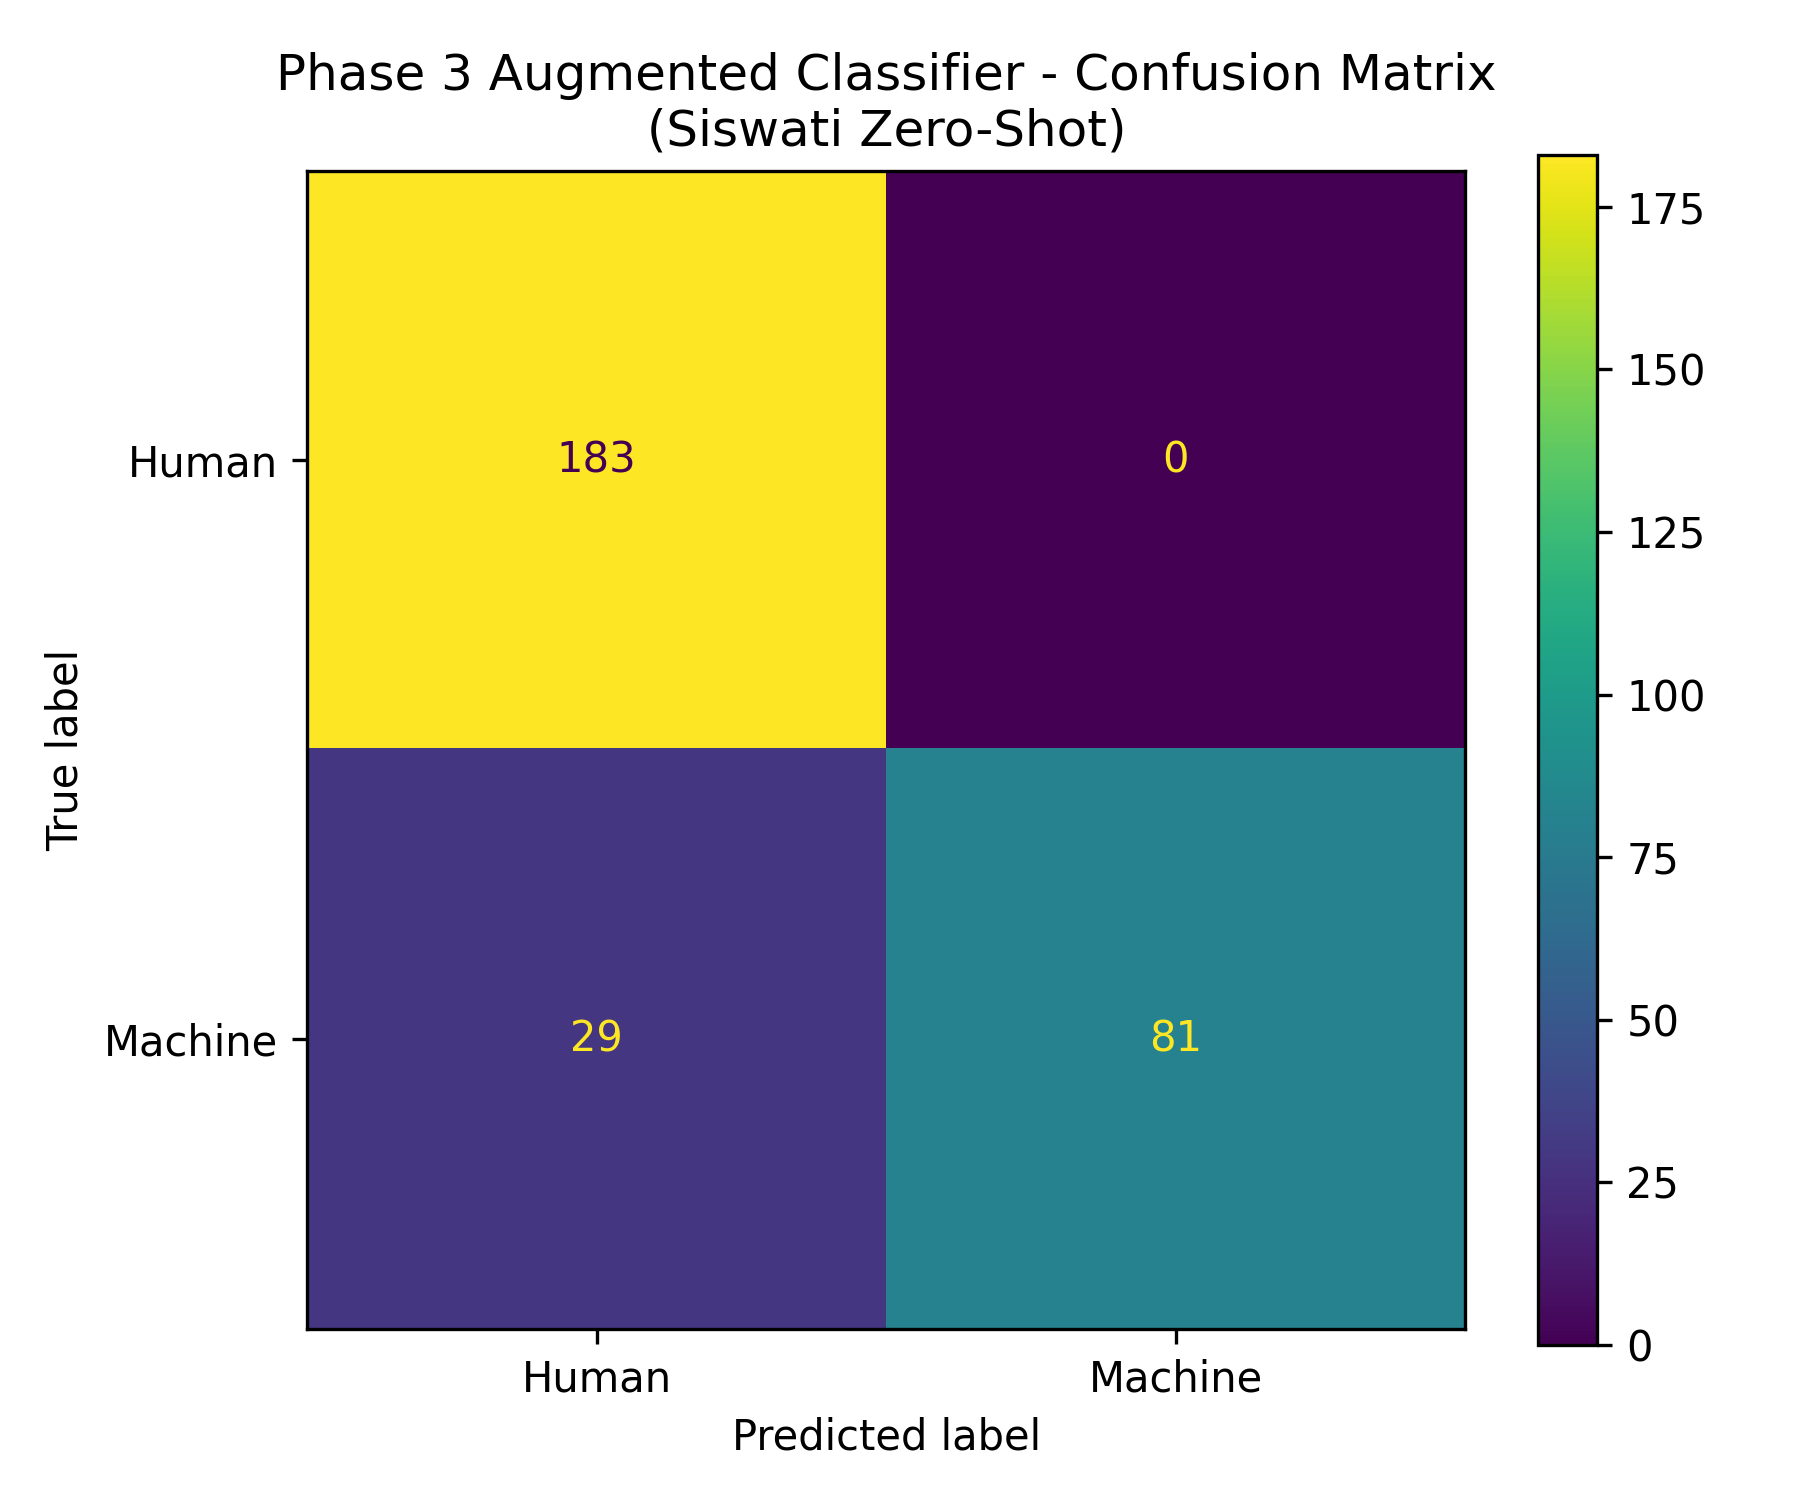


p3_feature_importance.png


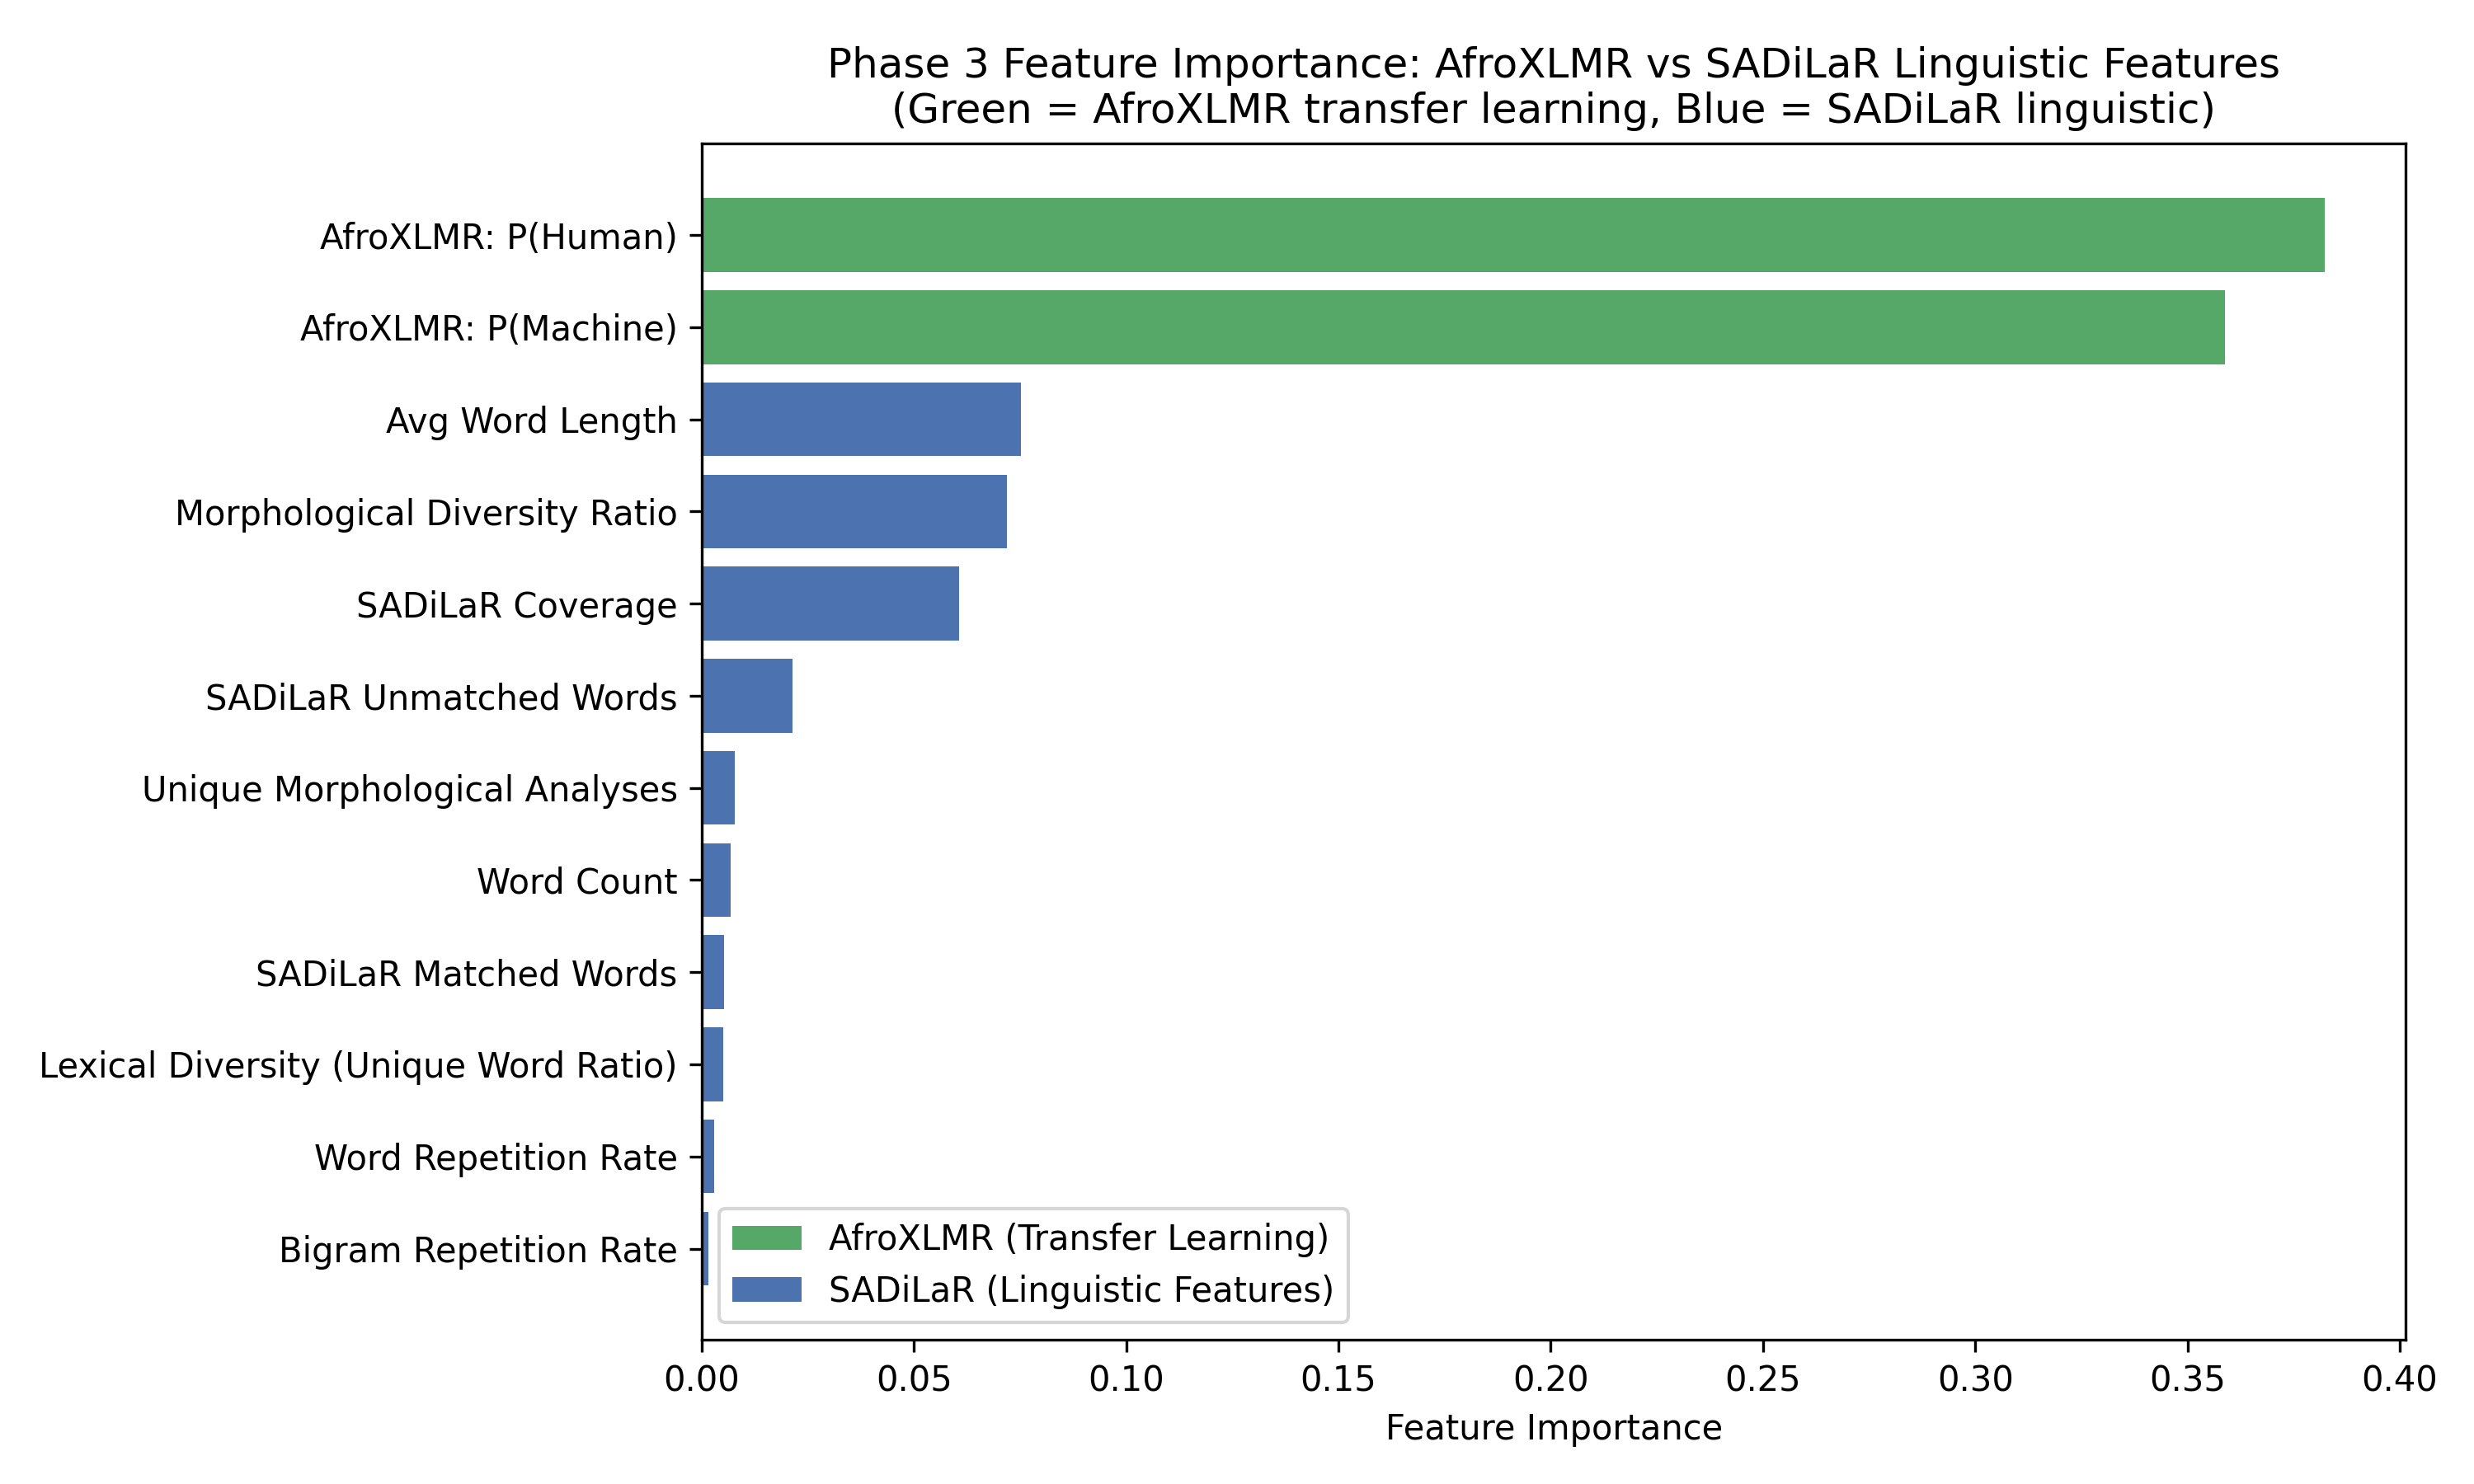


p3_phase_comparison.png


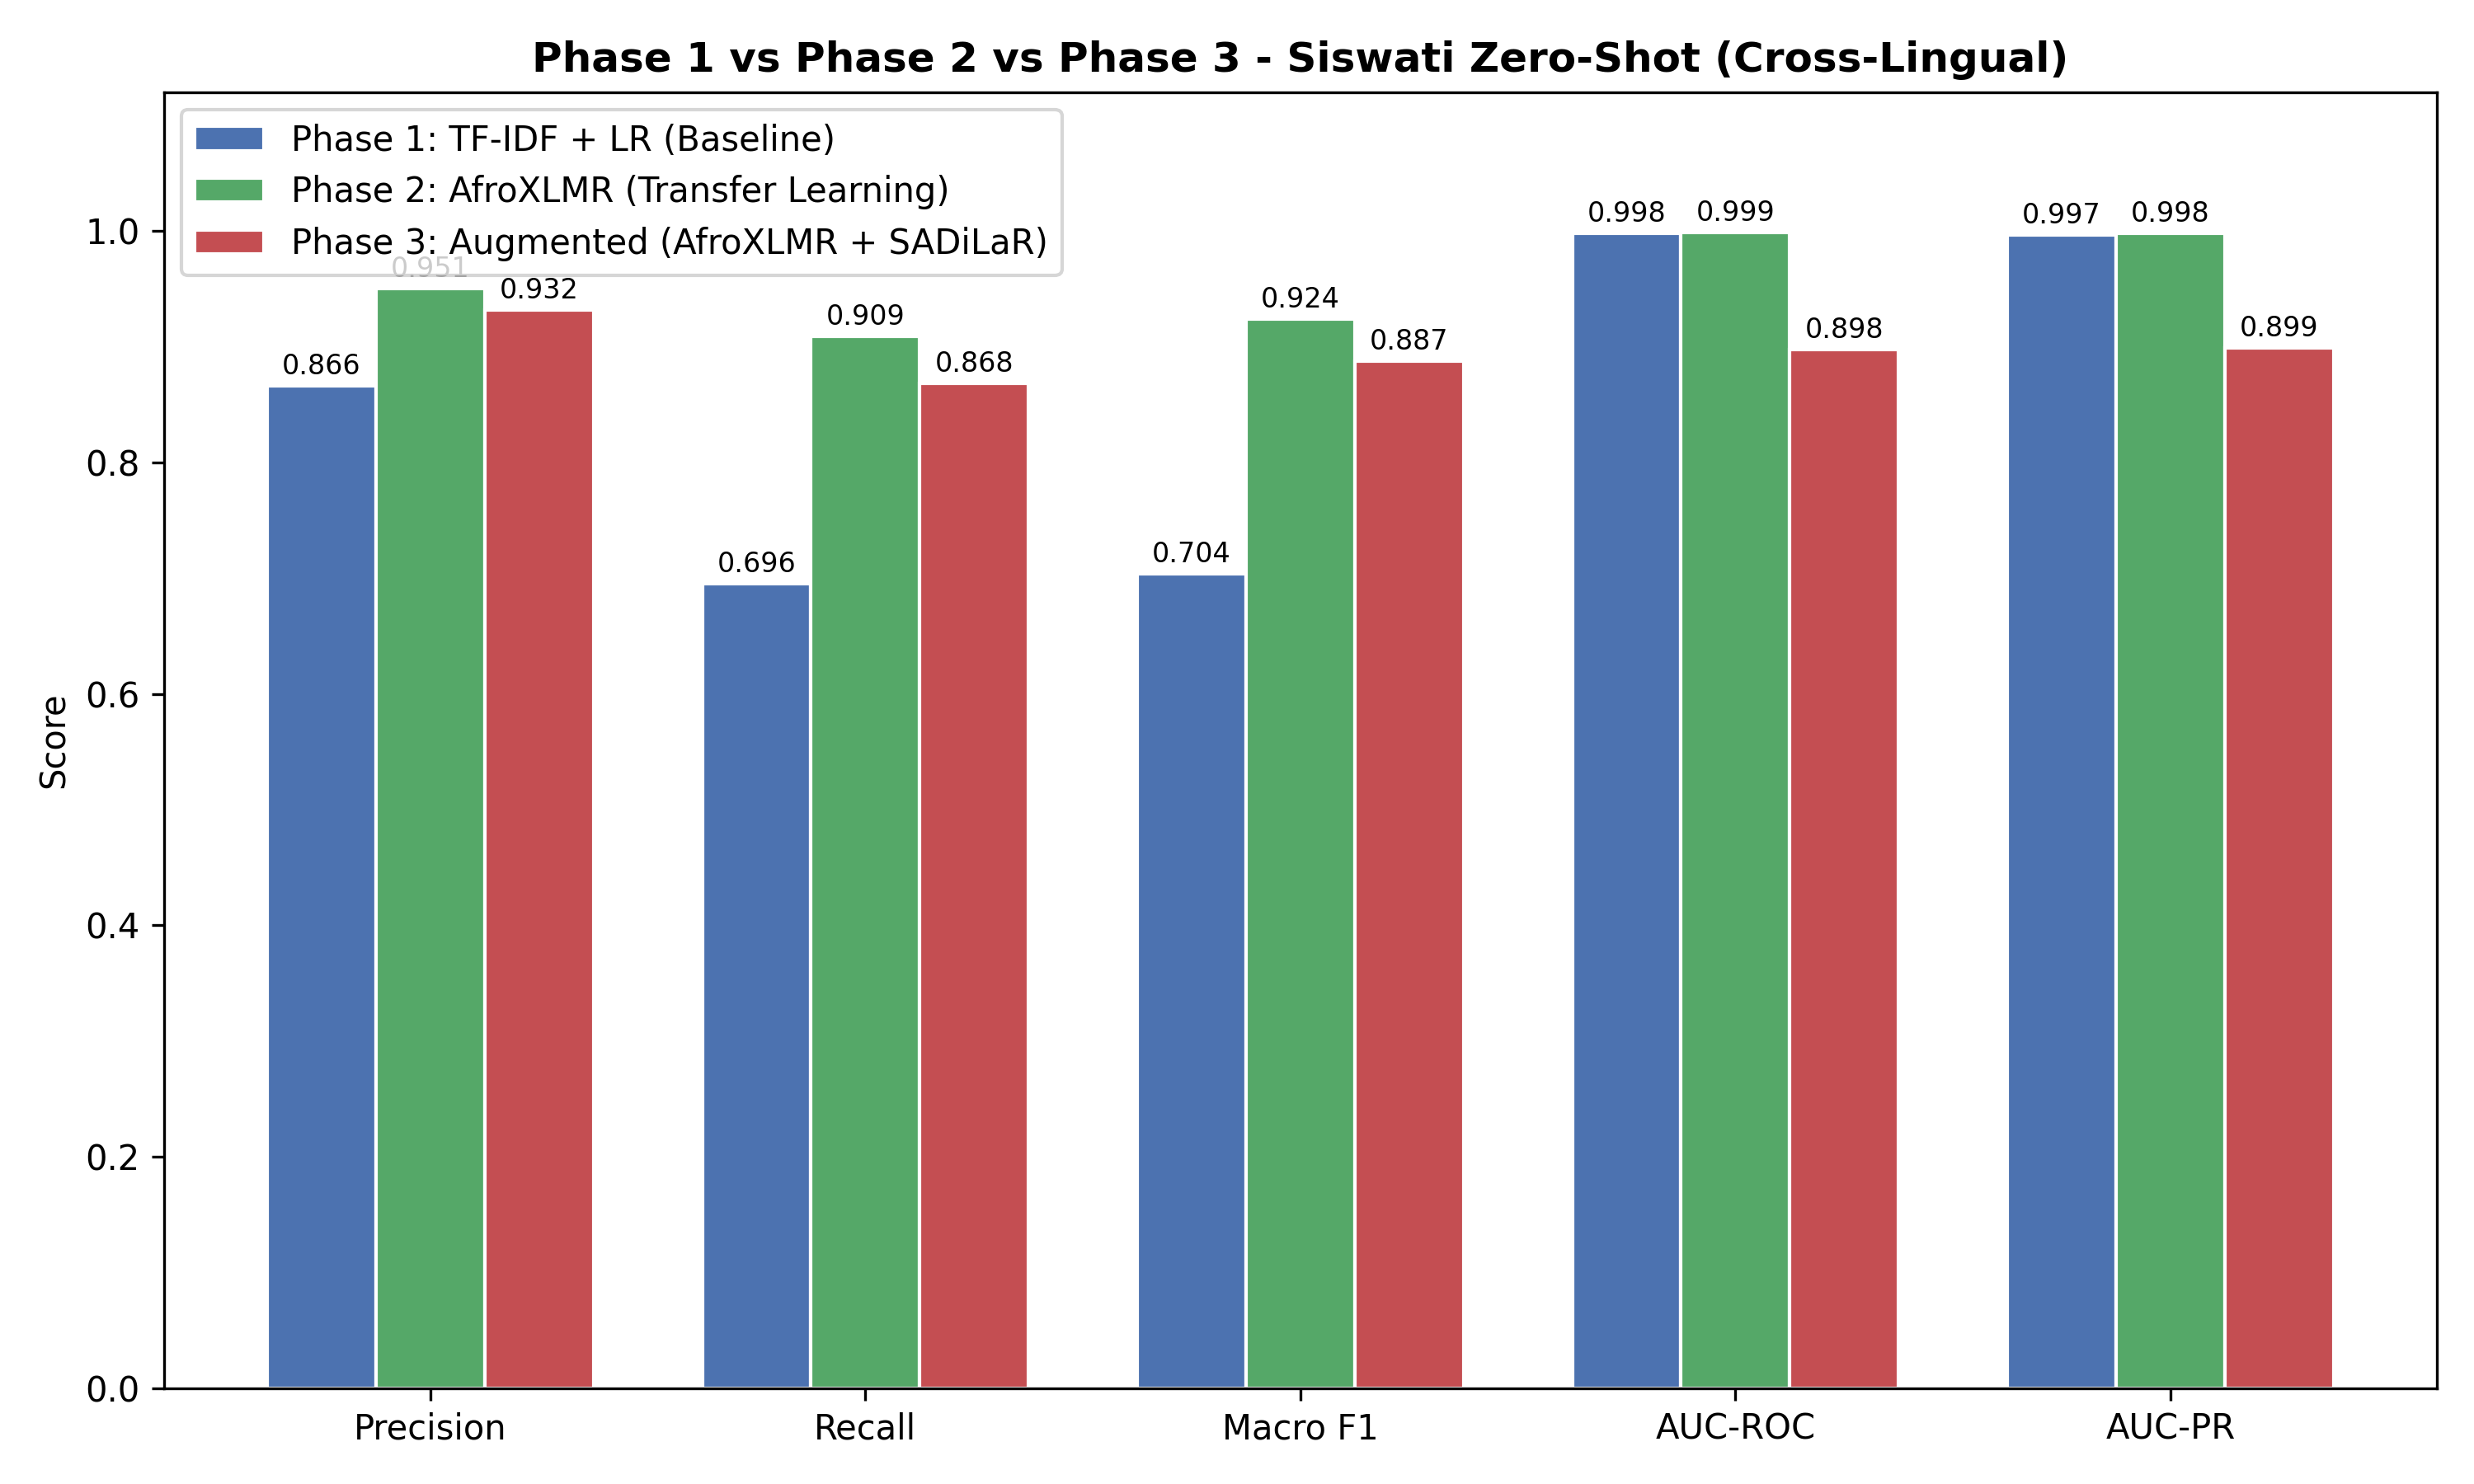


p3_cross_llm_bar.png


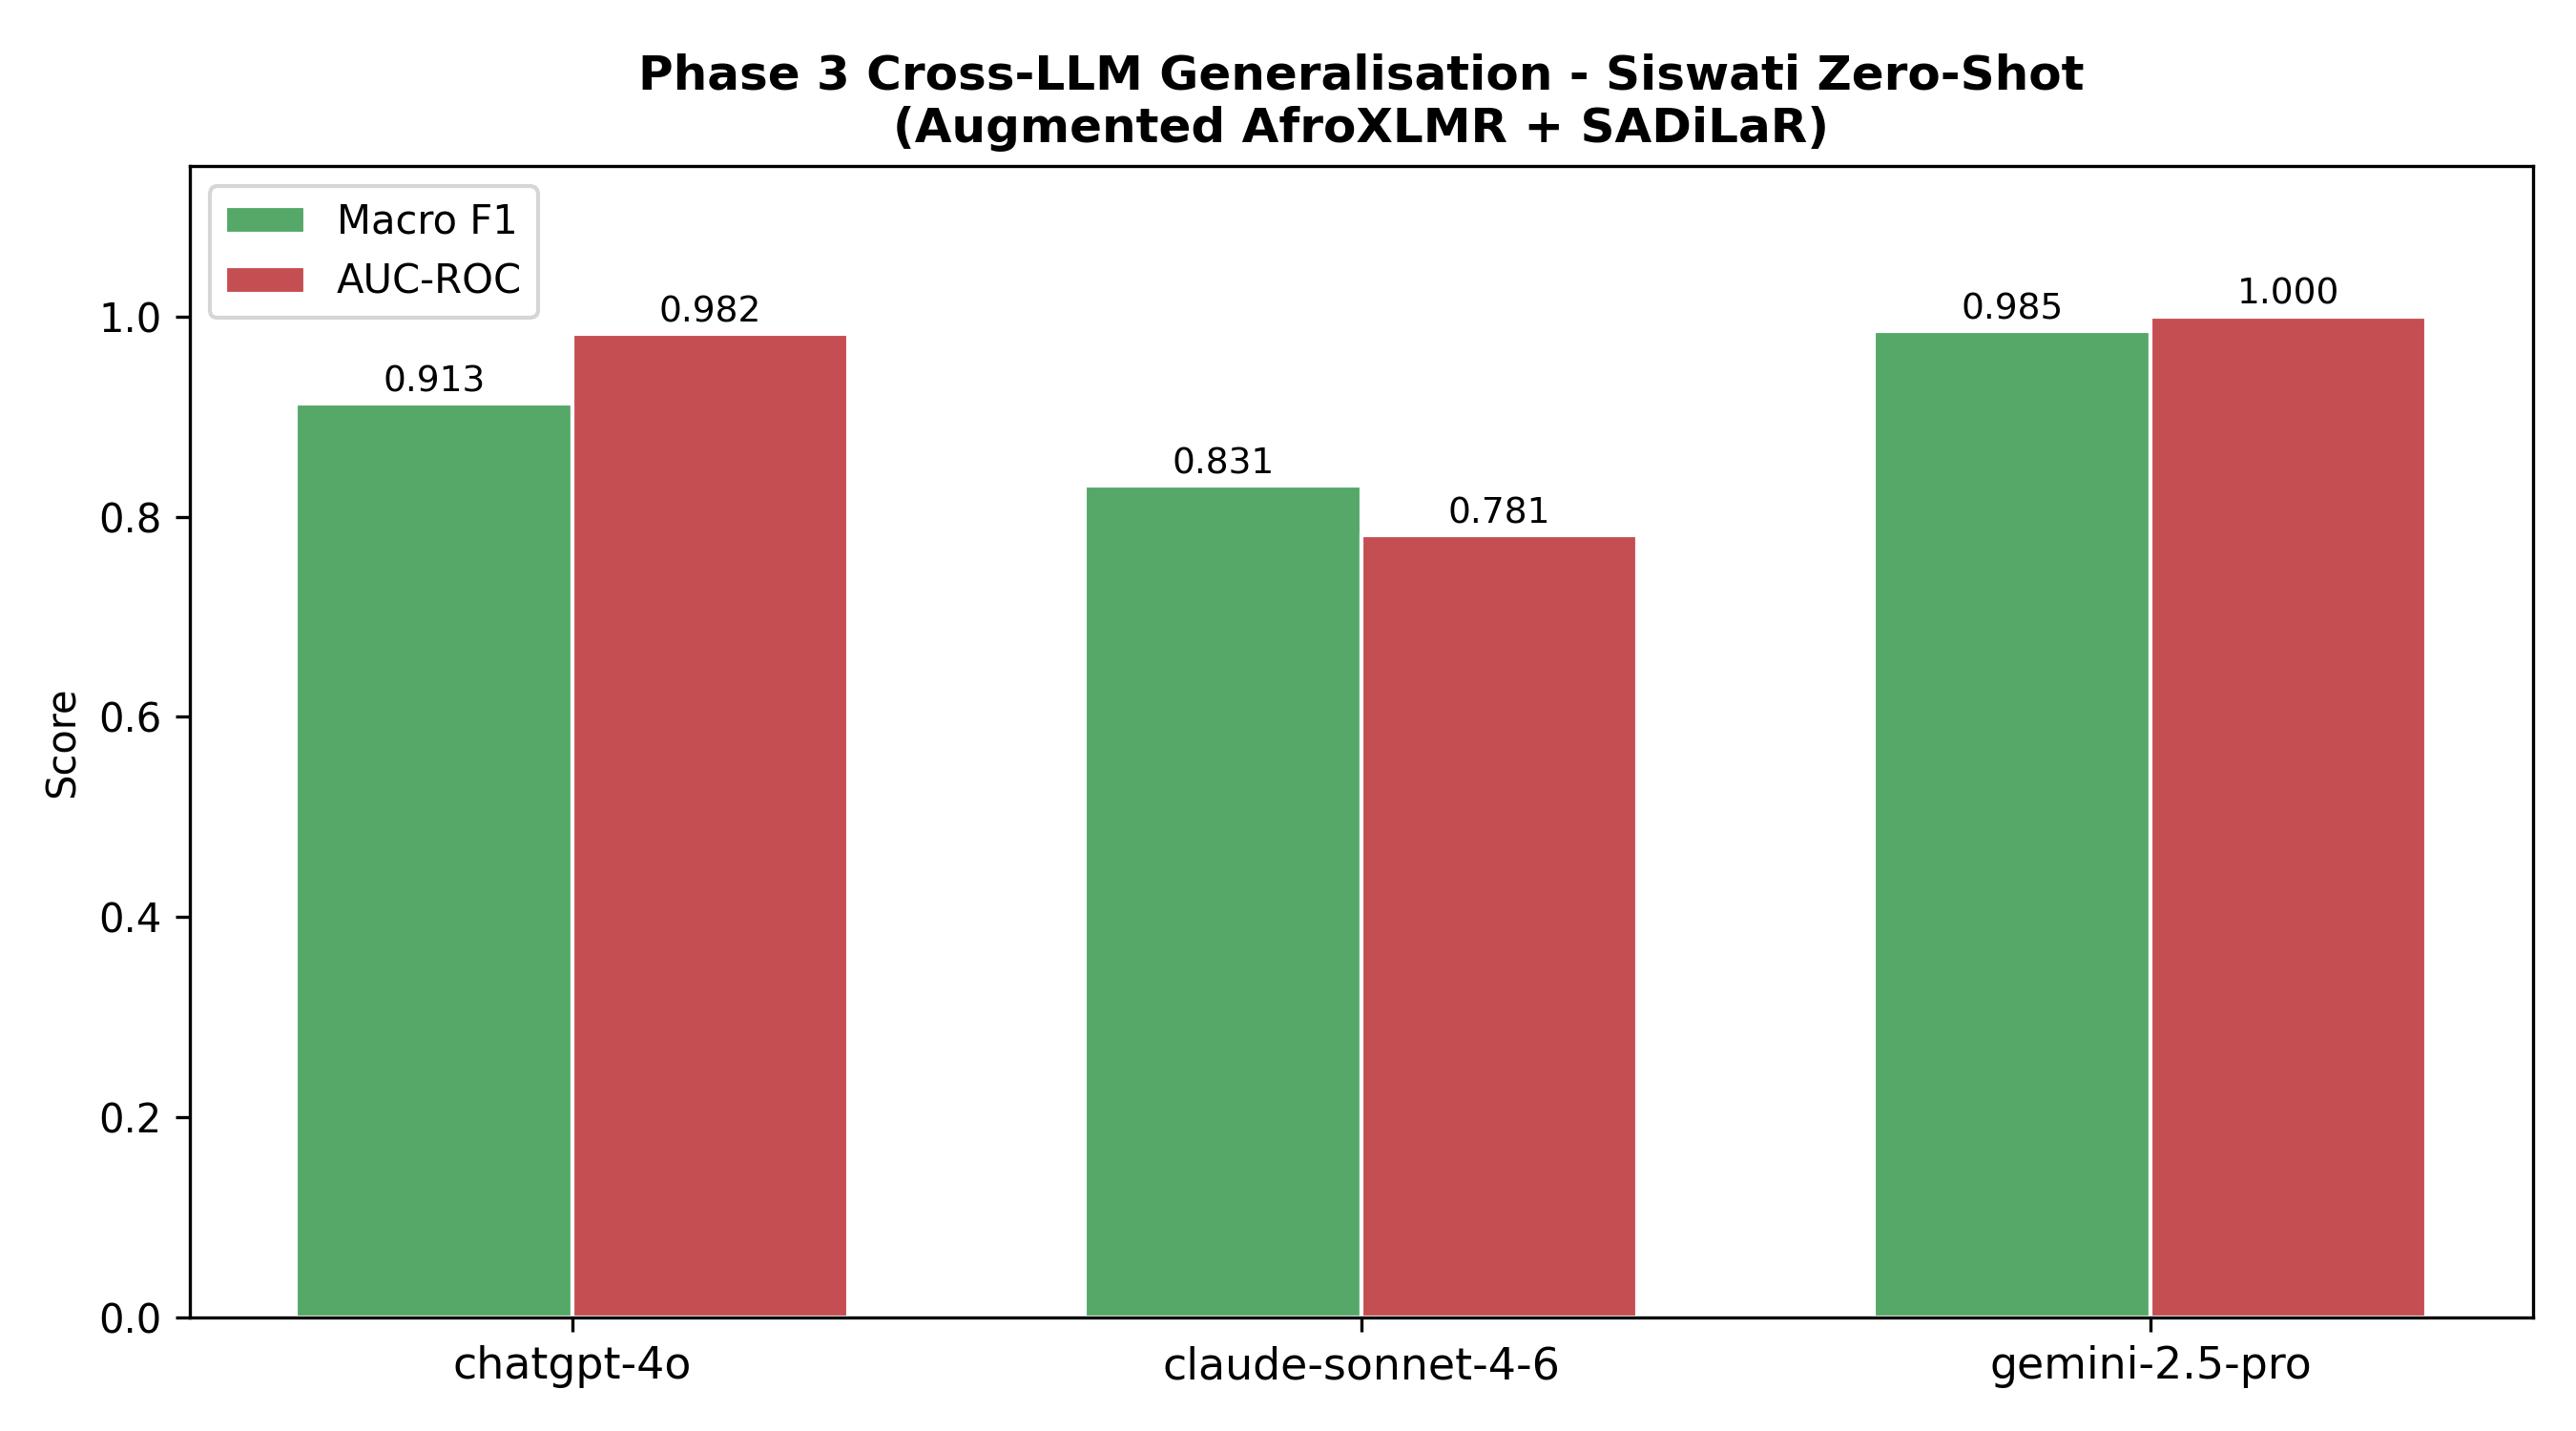


p3_shap_summary.png


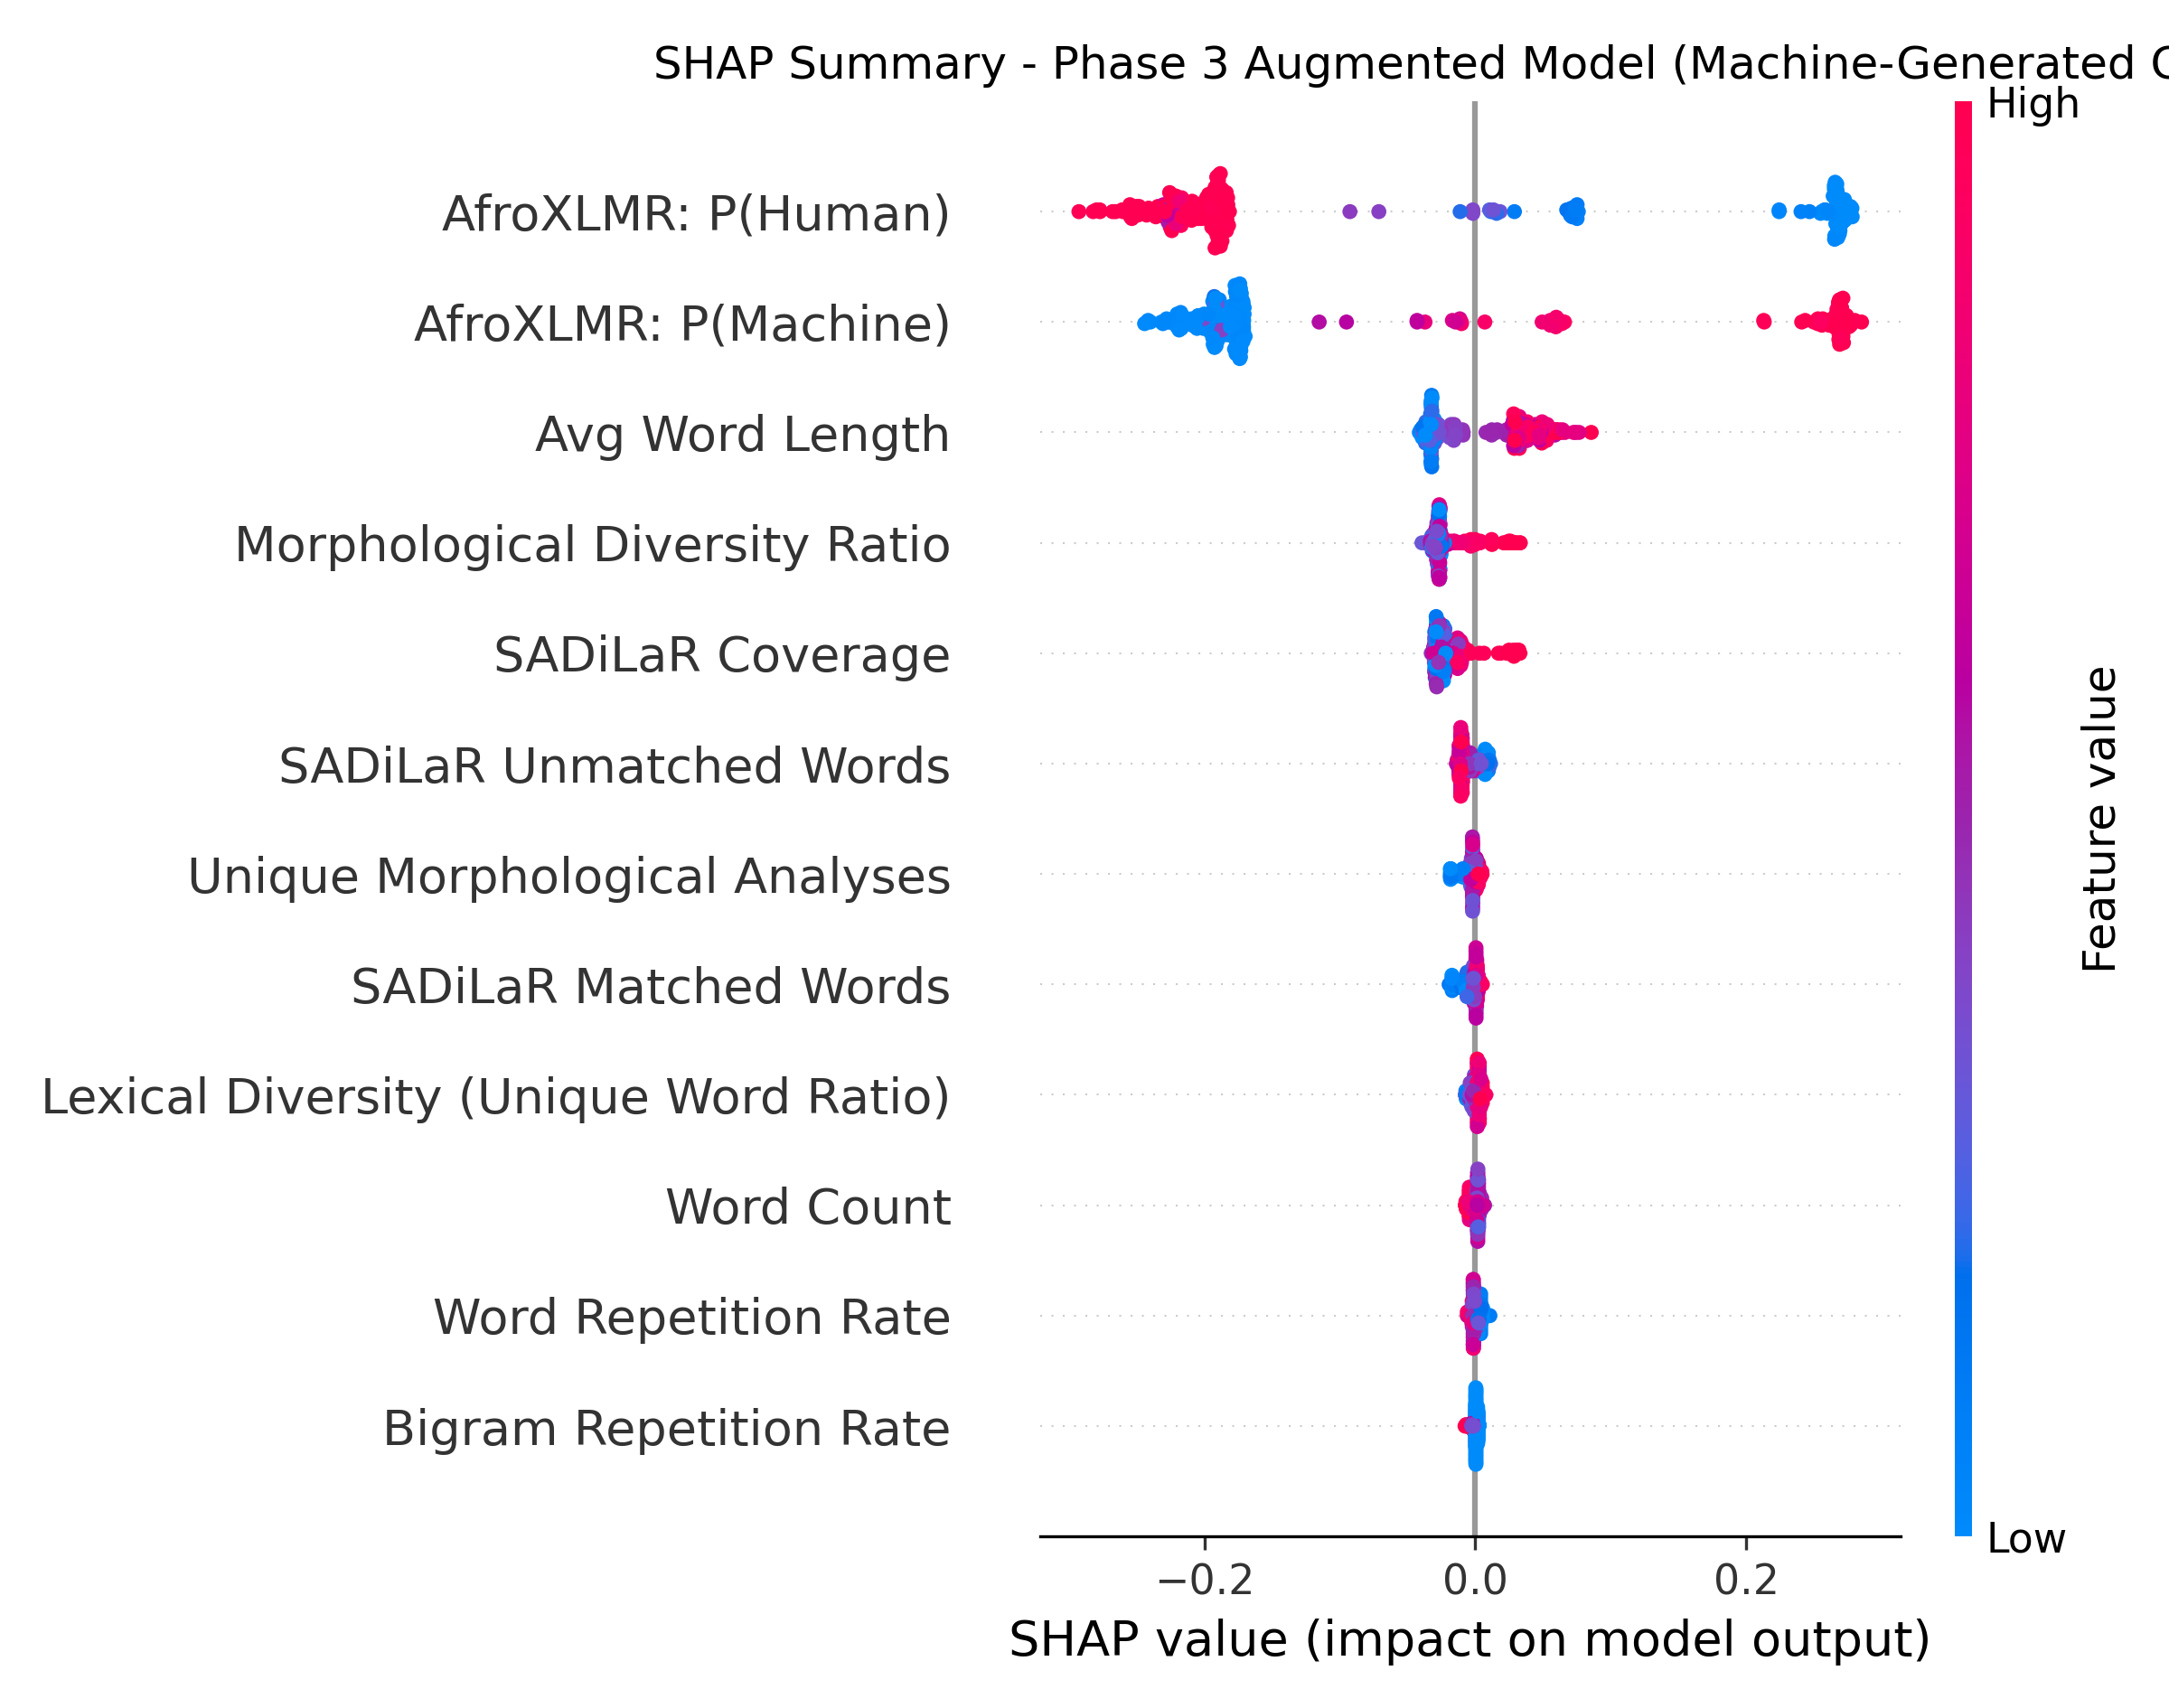


p3_shap_bar.png


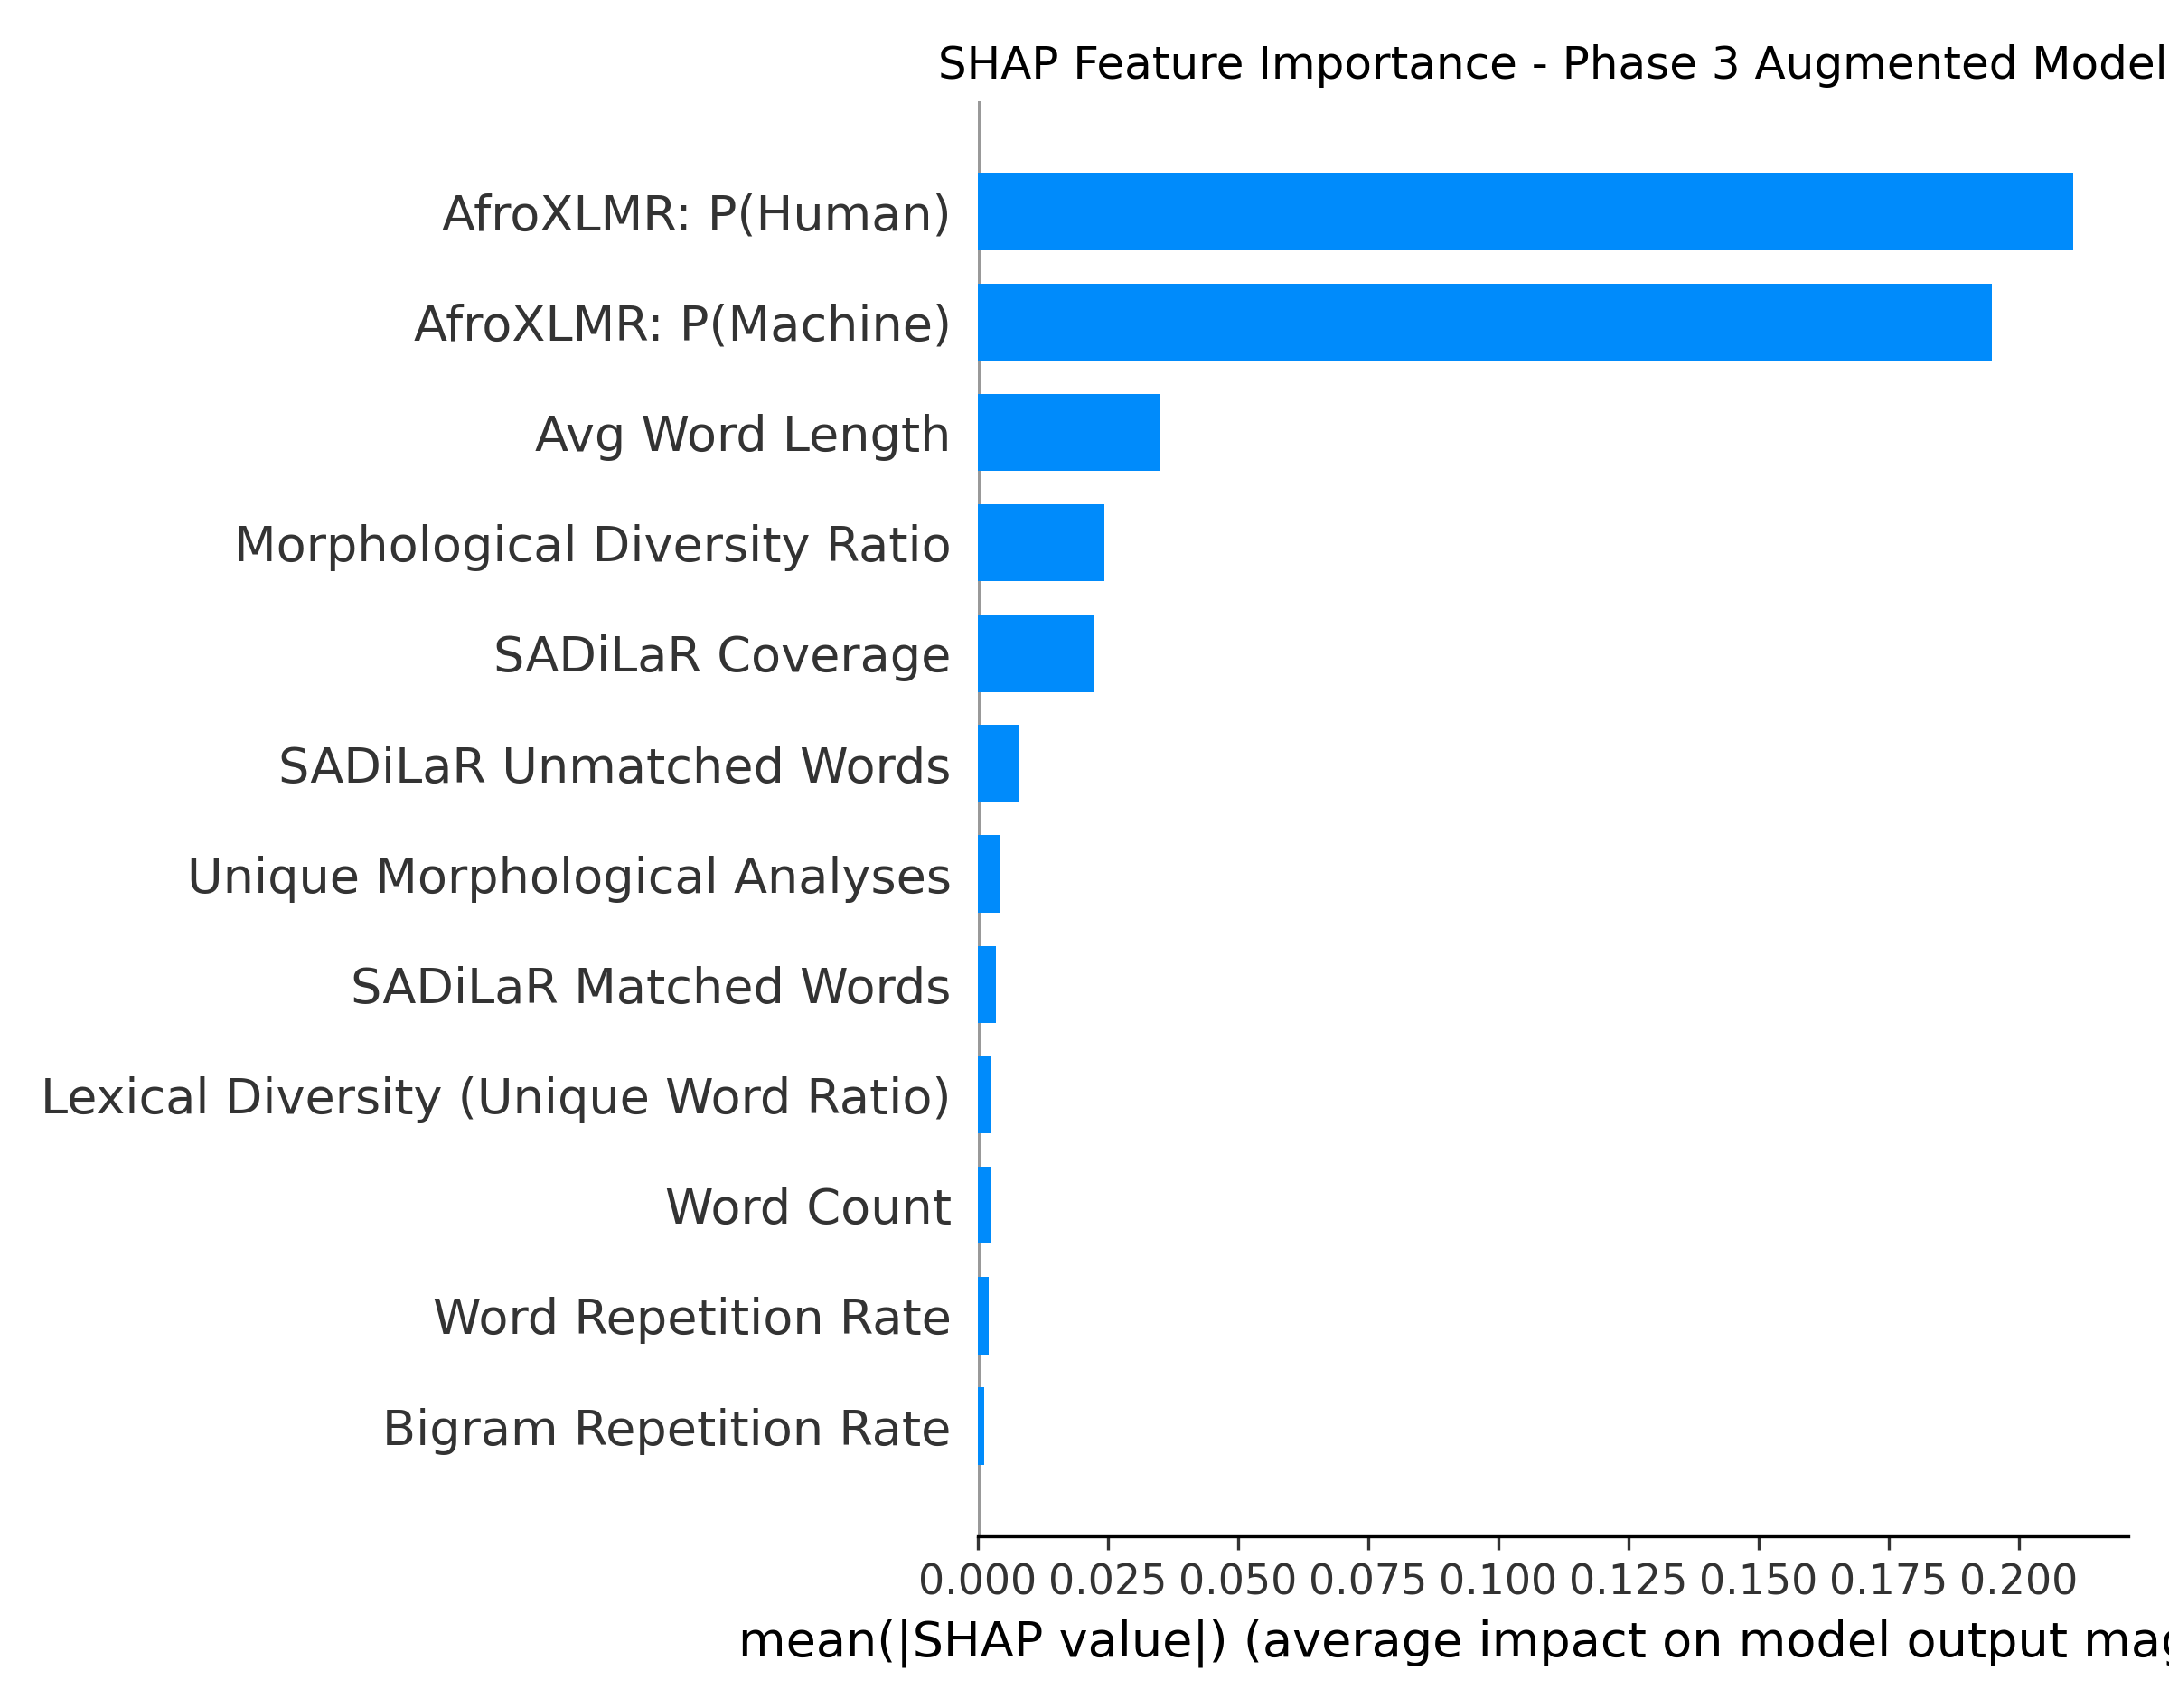

In [107]:
from IPython.display import Image, display
import os

RESULTS_DIR = "/content/drive/MyDrive/COS760-Group-45-main/results/sadilar_analysis"

plot_files = [
    "p3_confusion_matrix.png",
    "p3_feature_importance.png",
    "p3_phase_comparison.png",
    "p3_cross_llm_bar.png",
    "p3_shap_summary.png",
    "p3_shap_bar.png",
]

for plot in plot_files:
    path = os.path.join(RESULTS_DIR, plot)
    if os.path.exists(path):
        print(f"\n{plot}")
        display(Image(filename=path))
    else:
        print(f"Missing: {plot}")